# Нейромодератор v0.1

**Описание программы**

Программа предназначена для упрощения модерации публичных чатов и комментариев. Представляет собой модели, обученные классическими методами машинного обучения распознавать 4 вида сообщений:

1. INSULT - сообщения с оскорблениями
2. THREAT - сообщения с угрозами
3. OBSCENITY - сообщенеия с сексуальным подтекстом
4. NORMAL - сообщения без нарушений

После анализа сообщения, нейромодератор помечает сообщение одной или несколькими метками (мультиметкой), что позволяет значительно уменьшить объем работы модераторам или автоматизировать процесс модерации.

**Используемые материалы**

1. alexandersemiletov/toxic-russian-comments - Основной датасет русских комментариев. Содержит 4 основные метки. Встречаются "мультиметки".

2. reihanenamdari/youtube-toxicity-data - Дополнительный датасет из англоязычного сегмента Youtube.

3. jahangirhussen/toxic-comment - Дополнительный англоязычный датасет из соцсетей.

4. ilyaxin/Russian-Swear-Words - Датасет представляет собой словарь русского мата.

**Используемые алгоритмы машинного обучения**

1. XGBoost — это оптимизированная реализация алгоритма градиентного бустинга (Gradient Boosting) на деревьях решений. Это ансамблевый метод, который последовательно строит множество слабых моделей (неглубоких деревьев), где каждая следующая модель исправляет ошибки предыдущих.

2. LightGBM (Light Gradient Boosting Machine) — это высокопроизводительная библиотека для машинного обучения, основанная на алгоритме градиентного бустинга над деревьями решений.

3. Linear SVC — это линейный метод классификации, основанный на методе опорных векторов (SVM, Support Vector Machine), но оптимизированный специально для линейно разделимых или почти линейно разделимых данных. Это как «упрощённая» и часто более эффективная версия SVM для случая, когда границу между классами можно провести прямой линией (или гиперплоскостью в многомерном пространстве).

4. MLP (Multi-Layer Perceptron) — это фундаментальный тип искусственной нейронной сети прямого распространения (feedforward), который лежит в основе глубокого обучения.

**Почему нельзя просто взять готовую модель?**

Использование готовой предобученной модели (например, BERT/RuBERT/Detoxify) не решает поставленную задачу корректно по следующим причинам:

1. Готовые модели обучаются на новостях, Wikipedia, формальных текстах,очищенных корпусах. Модель может показывать высокую метрику на “чистых” тестах, но ошибаться на реальных пользовательских данных. Наши данные принципиально другие. Обучение проходит на комментариях пользователей и разговорной речи c использованием сленга.

2. Готовые модели часто бинарные (toxic / non-toxic) либо используют другую систему меток, не оптимизированы под мультиметки и не умеют корректно работать с перекрывающимися классами. В нашем случае используется мультиметочная классификация, независимые метки (INSULT, THREAT, OBSCENITY, NORMAL), так же один текст может иметь несколько меток.

3. Предобученная модель — это чёрный ящик. Неизвестно, какие паттерны она выучила. Сложно понять, почему принято конкретное решение и так же сложно откалибровать пороги для каждой метки. В нашем подходе каждая метка — отдельный бинарный классификатор. Можно анализировать ошибки, менять веса, подбирать threshold(порог вероятности), дообучать под конкретную метку. Наш подход гораздо более интерпретируемый и управляемый.

4. Ограничения по вычислительным ресурсам. Готовые модели требуют GPU, долго работают в инференсе(работа модели на новых данных) и плохо масштабируются. Наши модели быстрые, работают на CPU и подходят для production-сценариев с ограниченными ресурсами. GPU используется исключительно для перевода.

# ПРИМЕЧАНИЕ

Если хотите запустить код в Jupiter Notebook локально, убедитесь, что у Вас установлено 32+ Gb ОЗУ и размер файла подкачки регулируется динамически или установлен на 32+ Gb. Версию Cuda нужно подобрать в соответствии с вашей видеокартой (у меня Cuda 13.0).

**Конфигурация среды выполнения**

```
**Name**                  **Version**          **Build**        **Channel**
accelerate                 1.12.0              pypi_0           pypi
aiohappyeyeballs           2.6.1               pypi_0           pypi
aiohttp                    3.13.3              pypi_0           pypi
aiosignal                  1.4.0               pypi_0           pypi
anyio                      4.12.1              pypi_0           pypi
asttokens                  3.0.1               pypi_0           pypi
async-timeout              5.0.1               pypi_0           pypi
attrs                      25.4.0              pypi_0           pypi
blas                       1.0                 mkl
bleach                     6.3.0               pypi_0           pypi
brotlicffi                 1.2.0.0             py310h885b0b7_0
bzip2                      1.0.8               h2bbff1b_6
ca-certificates            2025.12.2           haa95532_0
certifi                    2026.01.04          py310haa95532_0
cffi                       2.0.0               py310h02ab6af_1
charset-normalizer         3.4.4               py310haa95532_0
click                      8.3.1               pypi_0           pypi
colorama                   0.4.6               pypi_0           pypi
comm                       0.2.3               pypi_0           pypi
contourpy                  1.3.2               pypi_0           pypi
cuda-cccl                  13.1.115            h415d894_0       nvidia
cuda-cccl_win-64           13.1.115            hc667259_0       nvidia
cuda-cudart                11.8.89             0                nvidia
cuda-cudart-dev            11.8.89             0                nvidia
cuda-cupti                 11.8.87             0                nvidia
cuda-libraries             11.8.0              0                nvidia
cuda-libraries-dev         11.8.0              0                nvidia
cuda-nvrtc                 11.8.89             0                nvidia
cuda-nvrtc-dev             11.8.89             0                nvidia
cuda-nvtx                  11.8.86             0                nvidia
cuda-profiler-api          13.1.115            h415d894_0       nvidia
cuda-runtime               11.8.0              0                nvidia
cuda-version               13.1                hd92462c_3       nvidia
cycler                     0.12.1              pypi_0           pypi
datasets                   4.4.2               pypi_0           pypi
dawg-python                0.7.2               pypi_0           pypi
debugpy                    1.8.19              pypi_0           pypi
decorator                  5.2.1               pypi_0           pypi
dill                       0.4.0               pypi_0           pypi
docopt                     0.6.2               pypi_0           pypi
exceptiongroup             1.3.1               pypi_0           pypi
executing                  2.2.1               pypi_0           pypi
expat                      2.7.3               h885b0b7_4
filelock                   3.20.0              py310haa95532_0
fonttools                  4.61.1              pypi_0           pypi
freetype                   2.13.3              h0620614_0
frozenlist                 1.8.0               pypi_0           pypi
fsspec                     2025.10.0           pypi_0           pypi
giflib                     5.2.2               h7edc060_0
gmp                        6.3.0               h537511b_0
gmpy2                      2.2.2               py310h8598115_0
h11                        0.16.0              pypi_0           pypi
hf-xet                     1.2.0               pypi_0           pypi
httpcore                   1.0.9               pypi_0           pypi
httpx                      0.28.1              pypi_0           pypi
huggingface-hub            0.36.0              pypi_0           pypi
idna                       3.11                py310haa95532_0
intel-openmp               2023.1.0            h59b6b97_46320
ipykernel                  7.1.0               pypi_0           pypi
ipython                    8.38.0              pypi_0           pypi
ipywidgets                 8.1.8               pypi_0           pypi
jedi                       0.19.2              pypi_0           pypi
jinja2                     3.1.6               py310haa95532_0
joblib                     1.5.3               pypi_0           pypi
jpeg                       9f                  ha349fce_0
jupyter-client             8.8.0               pypi_0           pypi
jupyter-core               5.9.1               pypi_0           pypi
jupyterlab-widgets         3.0.16              pypi_0           pypi
kagglehub                  0.4.0               pypi_0           pypi
kagglesdk                  0.1.14              pypi_0           pypi
kiwisolver                 1.4.9               pypi_0           pypi
lcms2                      2.16                hb4a4139_0
lerc                       3.0                 hd77b12b_0
libcublas                  11.11.3.6           0                nvidia
libcublas-dev              11.11.3.6           0                nvidia
libcufft                   10.9.0.58           0                nvidia
libcufft-dev               10.9.0.58           0                nvidia
libcurand                  10.4.1.81           hd7d98ca_0       nvidia
libcurand-dev              10.4.1.81           hd7d98ca_0       nvidia
libcusolver                11.4.1.48           0                nvidia
libcusolver-dev            11.4.1.48           0                nvidia
libcusparse                11.7.5.86           0                nvidia
libcusparse-dev            11.7.5.86           0                nvidia
libdeflate                 1.17                h2bbff1b_1
libexpat                   2.7.3               h885b0b7_4
libffi                     3.4.4               hd77b12b_1
libjpeg-turbo              2.0.0               h196d8e1_0
libnpp                     11.8.0.86           0                nvidia
libnpp-dev                 11.8.0.86           0                nvidia
libnvjpeg                  11.9.0.86           0                nvidia
libnvjpeg-dev              11.9.0.86           0                nvidia
libpng                     1.6.50              h46444df_0
libtiff                    4.5.1               hd77b12b_0
libuv                      1.48.0              h827c3e9_0
libwebp                    1.3.2               hbc33d0d_0
libwebp-base               1.3.2               h3d04722_1
libzlib                    1.3.1               h02ab6af_0
lightgbm                   4.6.0               pypi_0           pypi
lz4-c                      1.9.4               h2bbff1b_1
markupsafe                 3.0.2               py310h827c3e9_0
matplotlib                 3.10.8              pypi_0           pypi
matplotlib-inline          0.2.1               pypi_0           pypi
mkl                        2023.1.0            h6b88ed4_46358
mkl-service                2.4.0               py310h827c3e9_2
mkl_fft                    1.3.11              py310h827c3e9_0
mkl_random                 1.2.8               py310hc64d2fc_0
mpc                        1.3.1               h827c3e9_0
mpfr                       4.2.1               h56c3642_0
mpmath                     1.3.0               py310haa95532_0
multidict                  6.7.0               pypi_0           pypi
multiprocess               0.70.18             pypi_0           pypi
nest-asyncio               1.6.0               pypi_0           pypi
networkx                   3.4.2               py310haa95532_0
nltk                       3.9.2               pypi_0           pypi
numpy                      2.0.1               py310h055cbcc_1
numpy-base                 2.0.1               py310h65a83cf_1
openjpeg                   2.5.2               hae555c5_0
openssl                    3.0.18              h543e019_0
packaging                  25.0                pypi_0           pypi
pandas                     2.3.3               pypi_0           pypi
parso                      0.8.5               pypi_0           pypi
pillow                     11.1.0              py310h096bfcc_0
pip                        25.3                pyhc872135_0
platformdirs               4.5.1               pypi_0           pypi
prompt-toolkit             3.0.52              pypi_0           pypi
propcache                  0.4.1               pypi_0           pypi
protobuf                   6.33.4              pypi_0           pypi
psutil                     7.2.1               pypi_0           pypi
pure-eval                  0.2.3               pypi_0           pypi
pyarrow                    22.0.0              pypi_0           pypi
pycparser                  2.23                py310haa95532_0
pygments                   2.19.2              pypi_0           pypi
pymorphy2                  0.9.1               pypi_0           pypi
pymorphy2-dicts-ru         2.4.417127.4579844  pypi_0           pypi
pyparsing                  3.3.1               pypi_0           pypi
pysocks                    1.7.1               py310haa95532_1
python                     3.10.19             h981015d_0
python-dateutil            2.9.0.post0         pypi_0           pypi
python-slugify             8.0.4               pypi_0           pypi
pytorch-cuda               11.8                h24eeafa_6       pytorch
pytorch-mutex              1.0                 cuda             pytorch
pytz                       2025.2              pypi_0           pypi
pyyaml                     6.0.3               py310hb9a58be_0
pyzmq                      27.1.0              pypi_0           pypi
regex                      2025.11.3           pypi_0           pypi
requests                   2.32.5              py310haa95532_1
sacremoses                 0.1.1               pypi_0           pypi
safetensors                0.7.0               pypi_0           pypi
scikit-learn               1.7.2               pypi_0           pypi
scipy                      1.15.3              pypi_0           pypi
seaborn                    0.13.2              pypi_0           pypi
sentencepiece              0.2.1               pypi_0           pypi
setuptools                 80.9.0              pypi_0           pypi
shellingham                1.5.4               pypi_0           pypi
six                        1.17.0              pypi_0           pypi
sqlite                     3.51.1              hda9a48d_0
stack-data                 0.6.3               pypi_0           pypi
sympy                      1.14.0              py310haa95532_1
tbb                        2021.8.0            h59b6b97_0
text-unidecode             1.3                 pypi_0           pypi
threadpoolctl              3.6.0               pypi_0           pypi
tk                         8.6.15              hf199647_0
tokenizers                 0.22.2              pypi_0           pypi
torch                      2.9.1+cu130         pypi_0           pypi
torchaudio                 2.5.1               py310_cu118      pytorch
torchvision                0.24.1+cu130        pypi_0           pypi
tornado                    6.5.4               pypi_0           pypi
tqdm                       4.67.1              pypi_0           pypi
traitlets                  5.14.3              pypi_0           pypi
transformers               4.57.5              pypi_0           pypi
typer-slim                 0.21.1              pypi_0           pypi
typing_extensions          4.15.0              py310haa95532_0
tzdata                     2025.3              pypi_0           pypi
ucrt                       10.0.22621.0        haa95532_0
urllib3                    2.6.3               py310haa95532_0
vc                         14.3                h2df5915_10
vc14_runtime               14.44.35208         h4927774_10
vs2015_runtime             14.44.35208         ha6b5a95_10
wcwidth                    0.2.14              pypi_0           pypi
webencodings               0.5.1               pypi_0           pypi
wheel                      0.45.1              py310haa95532_0
widgetsnbextension         4.0.15              pypi_0           pypi
win_inet_pton              1.1.0               py310haa95532_1
xgboost                    3.1.3               pypi_0           pypi
xxhash                     3.6.0               pypi_0           pypi
xz                         5.6.4               h4754444_1
yaml                       0.2.5               he774522_0
yarl                       1.22.0              pypi_0           pypi
zlib                       1.3.1               h02ab6af_0
zstd                       1.5.7               h56299aa_0
```



# ЧИСТКА КЕША

Нужна при повторном обучении или исправлении ошибок. Раскоментируйте и выполните при необходимости. Рекомендуется дополнительно перезапустить среду выполнения, если результат не оправдал ожиданий.

In [ ]:
#import torch;
#torch.cuda.empty_cache()
#from IPython.display import clear_output; clear_output()

In [ ]:
#!pip cache purge

# Пишем файл зависимостей (Для Colab)

In [ ]:
%%writefile requirements.txt
kagglehub
kaggle
pandas
numpy
matplotlib
seaborn
lightgbm
xgboost
transformers
sentencepiece
sacremoses
torch
tqdm
pymorphy2
pyarrow
joblib
datasets

Overwriting requirements.txt


# Устанавливаем библиотеки одним файлом

In [ ]:
!pip install -r requirements.txt

# Фикс XGBoost для Colab

In [ ]:
!pip install -U xgboost

# Импорты и настройки

Для начала соберем все самое необходимое

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import f1_score, hamming_loss, classification_report, recall_score
from sklearn.utils import resample
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.frozen import FrozenEstimator
from datasets import load_dataset
from scipy.sparse import hstack
from xgboost import XGBClassifier
from pathlib import Path
from tqdm import tqdm
tqdm.pandas()

import os
import re
import time
import random
import gc
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore")

try:
    import kagglehub
except Exception:
    raise RuntimeError("kagglehub не найден. Установите командой: `!pip install kagglehub`")

try:
    import torch
    from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
except Exception:
    raise RuntimeError("Установите transformers и torch: pip install transformers sentencepiece torch")


# ================= ПАРАМЕТРЫ =================

sns.set(style="whitegrid", font_scale=1.0)

# Максимальное количество словесных n-грамм, которые попадут в TF-IDF словарь
TFIDF_MAX_FEATURES = 30000
# Чем больше — тем:
# -лучше различаются редкие оскорбления
# -используется больше памяти
# -медленнее обучение

# Чем меньше — тем:
# -быстрее
# -выше риск потерять важные токсичные выражения

# Количество символьных n-грамм (например хуй, *уй, у@й) в TF-IDF словаре.
CHAR_TFIDF_MAX = 5000
# Менять не рекомендуется, создает много шума, кушает память!!!
# Ловит:
# -маскировку (х*й, f@ck)
# -опечатки
# -транслит

# Сжимает TF-IDF пространство (например 35k → 300 измерений).
SVD_COMPONENTS = 300
# SVD ускоряет обучение и снижает шум. Улучшает обобщение.
# 200-500 оптимально, выше медленно, ниже бессмысленно

# Максимальная длина текста при переводе.
TRANSLATION_MAX_TOKENS = 128
# 128 оптимально. Чем больше, тем дольше, на качество почти не влияет.

# Фиксирует генераторы случайных чисел
RANDOM_STATE = 42
# Дает одинаковые результаты между запусками
# Позволяет корректно сравнивать модели

# Файл с уже сгенерированными синтетическими примерами.
SWEAR_CACHE = "swear_generated.csv"

# Кеши перевода
YT_TRANSL_CACHE = "yt_translated_ru.parquet"
TOXIC_TRANSL_CACHE = "toxic_translated_ru.parquet"
TRANSLATION_CACHE = "translation_cache.parquet"

# Итоговый обучающий датасет
COMBINED_CSV = "combined_dataset.csv"

# Множители балансировки. Чем реже метка, тем выше множитель.
# Множитель < 0 запускает downsampling, > 0 upsampling
MULT_INSULT = 0.1 # встречается слишком часто в финальном датасете
MULT_THREAT = 4.0 # редкий
MULT_OBSCENITY = 6.0 # много форм, часто маскируется, тяжело ловится
# Оверсемплинг / даунсэмплинг балансирует классы без удаления данных,
# увеличивая редкие метки и уменьшая доминирующие.

# Папка для хранения кеша моделей
CACHE_DIR = "models_cache"
os.makedirs(CACHE_DIR, exist_ok=True)


# КЕШИРОВАНИЕ TF-IDF + SVD

FEATURE_CACHE      = Path("feature_cache")
FEATURE_CACHE.mkdir(exist_ok=True)

TFIDF_WORD_PATH    = FEATURE_CACHE / "tfidf_word.pkl"
TFIDF_CHAR_PATH    = FEATURE_CACHE / "tfidf_char.pkl"
SVD_PATH           = FEATURE_CACHE / f"svd_{SVD_COMPONENTS}.pkl"

# TF-IDF sparse матрицы
X_TRAIN_TFIDF_PATH = FEATURE_CACHE / "X_train_tfidf_sparse.npz"
X_VAL_TFIDF_PATH   = FEATURE_CACHE / "X_val_tfidf_sparse.npz"
X_TEST_TFIDF_PATH  = FEATURE_CACHE / "X_test_tfidf_sparse.npz"

# SVD sparse матрицы
X_TRAIN_SVD_PATH   = FEATURE_CACHE / "X_train_svd_sparse.npz"
X_VAL_SVD_PATH     = FEATURE_CACHE / "X_val_svd_sparse.npz"
X_TEST_SVD_PATH    = FEATURE_CACHE / "X_test_svd_sparse.npz"

# META sparse матрицы
META_TRAIN_PATH    = FEATURE_CACHE / "meta_train_sparse.npz"
META_VAL_PATH      = FEATURE_CACHE / "meta_val_sparse.npz"
META_TEST_PATH     = FEATURE_CACHE / "meta_test_sparse.npz"

# ФИНАЛЬНЫЕ МАТРИЦЫ
X_TRAIN_MLP_PATH   = FEATURE_CACHE / "X_train_mlp_sparse.npz"
X_VAL_MLP_PATH     = FEATURE_CACHE / "X_val_mlp_sparse.npz"
X_TEST_MLP_PATH    = FEATURE_CACHE / "X_test_mlp_sparse.npz"

**Проверка доступности CUDA**

In [ ]:
print(f"CUDA доступна: {torch.cuda.is_available()}")  # Должно быть True
if torch.cuda.is_available():
    # Проверка устройства
    print(f"Устройство: {torch.cuda.get_device_name(0)}")
    # Проверка версии CUDA, с которой собран PyTorch
    print(f"Версия CUDA в PyTorch: {torch.version.cuda}")

CUDA доступна: True
Устройство: NVIDIA GeForce RTX 3070 Laptop GPU
Версия CUDA в PyTorch: 13.0


# ИНИЦИАЛИЗАЦИЯ МОДЕЛИ ПЕРЕВОДА

Так как для обучения моделей используются англоязычные датасеты, их нужно перевести на русский язык. С этой задачей хорошо справляется модель NLLB.

In [ ]:
print("Инициализация модели NLLB для перевода...")

# Определяем устройство
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Устройство: {device}")

# Загружаем модель и токенизатор
model_name = "facebook/nllb-200-distilled-600M"  # Модель для перевода

tokenizer = AutoTokenizer.from_pretrained(model_name, src_lang="eng_Latn")  # Исходный язык - английский
# Загружаем модель. Если GPU, используем fp16 для скорости
if device == "cuda":
    model = AutoModelForSeq2SeqLM.from_pretrained(
        model_name,
        dtype=torch.float16,
        device_map="auto"
    )
else:
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)

# Определяем целевую переменную TGT_LANG, которую используют функции
TGT_LANG = "rus_Cyrl"  # Языковой код для русского в модели NLLB

print(f"Модель '{model_name}' загружена. Целевой язык: {TGT_LANG}")

Инициализация модели NLLB для перевода...
Устройство: cuda
Модель 'facebook/nllb-200-distilled-600M' загружена. Целевой язык: rus_Cyrl


# Функции

Смотрим в будущее. Если код будет запускаться не в ноутбуке, а как отдельное ПО локально, то данный блок можно записать в отдельный файл и подключать в других как библиотеку.

In [ ]:
def read_first_n_lines(filename, n=5):
    """Эффективное чтение первых n строк больших файлов"""
    lines = []
    with open(filename, 'r', encoding='utf-8') as f:
        try:
            for i in range(n):
                lines.append(next(f).rstrip('\n'))
        except StopIteration:
            pass  # Файл закончился раньше
    return lines

def run_text_eda(
    df,
    text_col,
    label_col=None,
    title="Dataset",
    max_len=1000
):
    """
    Проводит EDA (развернутый анализ) для датасета
    """
    print(f"\n=== EDA: {title} ===")
    print("Размер:", df.shape)

    empty = df[text_col].isna().sum() + (df[text_col].astype(str).str.strip() == "").sum()
    print("Пустые тексты:", empty)

    lengths = df[text_col].astype(str).apply(lambda x: len(x.split()))
    print("Средняя длина (слов):", round(lengths.mean(), 2))

    plt.figure(figsize=(6, 3))
    sns.histplot(lengths[lengths <= max_len], bins=40)
    plt.title(f"{title}: распределение длины текстов")
    plt.xlabel("Кол-во слов")
    plt.show()

    if label_col is not None and label_col in df.columns:
        print("\nРаспределение меток:")
        lab_counts = df[label_col].explode().value_counts()
        display(lab_counts)

        plt.figure(figsize=(6, 4))
        sns.barplot(x=lab_counts.index, y=lab_counts.values)
        plt.title(f"{title}: распределение меток")
        plt.xticks(rotation=45)
        plt.show()


def demask_text(text):
    """
    ДЕМАСКИРОВКА ТЕКСТА
    """
    if not isinstance(text, str):
        return ""

    t = text
    t = re.sub(
        r'([A-Za-zА-Яа-яёЁ])[\@\$\*\#\!\?]+([A-Za-zА-Яа-яёЁ])',
        r'\1\2',
        t
    )

    patterns = {
        r"sh\*t": "shit",
        r"sh\*\*t": "shit",
        r"f\*ck": "fuck",
        r"a\$\$": "ass",
        r"b\@tch": "bitch",
        r"bi\@tch": "bitch",
        r"f\*\*k": "fuck",
        r"fu\*k": "fuck",
    }

    for p, rpl in patterns.items():
        t = re.sub(p, rpl, t, flags=re.IGNORECASE)

    t = re.sub(r"х[\*\@\$\#\!\?]{1,}й", "хуй", t, flags=re.IGNORECASE)
    t = re.sub(r"[её][\*\@\$\#\!\?]{1,}б", "еб", t, flags=re.IGNORECASE)
    t = re.sub(r"п[\*\@\$\#\!\?]{1,}зда", "пизда", t, flags=re.IGNORECASE)
    t = re.sub(r"г[\*\@\$\#\!\?]{1,}ндон", "гандон", t, flags=re.IGNORECASE)

    t = re.sub(r'([а-яёa-z])\1{2,}', r'\1\1', t, flags=re.IGNORECASE)
    return t


def clean_minimal(text):
    """
    ЧИСТКА ТЕКСТА
    """
    t = str(text).lower()
    t = re.sub(r"http\S+", " ", t)
    t = re.sub(r"<[^>]+>", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t


def normalize_for_translation(s):
    """
    Нормализация перед переводом
    """
    if not isinstance(s, str):
        return ""
    return " ".join(s.split())


def _generate_for_tokenized(tokenized_inputs, max_length):
    """
    Выполняет генерацию перевода через seq2seq-модель (NLLB, Marian и т.п.).
    Использует model.generate(...)
    Принудительно задаёт язык назначения (forced_bos_token_id)
    Работает без градиентов (torch.no_grad())
    Возвращает декодированный текст.
    """
    with torch.no_grad():
        out = model.generate(
            **tokenized_inputs,
            max_length=max_length,
            num_beams=4,
            forced_bos_token_id=tokenizer.convert_tokens_to_ids(TGT_LANG),
            use_cache=True
        )
    return tokenizer.batch_decode(out, skip_special_tokens=True)


def tokenize_batches(
    texts,
    batch_size=64,
    max_length=TRANSLATION_MAX_TOKENS
):
    """
    Разбивает тексты на батчи и токенизирует их.
    Делит список текстов на чанки.
    Нормализует текст перед переводом.
    Применяет tokenizer(...).
    Возвращает исходные батчи и список токенизированных словарей
    """
    batches = [texts[i:i + batch_size] for i in range(0, len(texts), batch_size)]
    tokenized_list = []

    for batch in tqdm(batches, desc="Tokenizing"):
        clean = [normalize_for_translation(t) for t in batch]

        tok = tokenizer(
            clean,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length
        )

        tokenized_list.append(tok)

    return batches, tokenized_list


def translate_texts_safe(
    texts,
    batch_size=64,
    max_length=256,
    n_workers=2,
    cache_file="translation_cache_nllb_v1.parquet"
):
    """
    Безопасный батч-перевод с кешированием и fallback-механизмом.
    - Загружает кеш перевода (parquet)
    - Определяет тексты, которые ещё не переводились
    - Переводит только новые
    - При ошибке батча переходит на перевод по одному тексту
    - Чистит GPU память после каждого батча
    - Обновляет кеш
    Возвращает итоговый список переводов
    """
    texts = ["" if t is None else str(t) for t in texts]
    df = pd.DataFrame({"original": texts})

    # Загрузка кеша
    if os.path.exists(cache_file):
        cache_df = pd.read_parquet(cache_file)
    else:
        cache_df = pd.DataFrame(columns=["original", "translated"])

    merged = df.merge(cache_df, on="original", how="left")
    need_mask = merged["translated"].isna()
    need_texts = merged.loc[need_mask, "original"].tolist()

    if not need_texts:
        return merged["translated"].tolist()

    batches, tokenized_list = tokenize_batches(
        need_texts,
        batch_size=batch_size,
        max_length=max_length
    )


    translated_new = []

    for idx, tok in enumerate(tqdm(tokenized_list, desc="Генерируем")):
        batch = batches[idx]

        if tok is None:
            clean = [normalize_for_translation(s) for s in batch]
            tok = tokenizer(clean, return_tensors="pt", padding=True, truncation=True, max_length=max_length)

        tok = {k: v.to(model.device) for k, v in tok.items()}

        try:
            out = _generate_for_tokenized(tok, max_length)
            if len(out) != len(batch):
                raise ValueError("Несоответствие длины")
            translated_new.extend(out)

        except Exception as e:
            print("Резервный вариант по причине:", e)
            for s in batch:
                s_norm = normalize_for_translation(s)
                tok_single = tokenizer(
                    [s_norm],
                    return_tensors="pt",
                    padding=True,
                    truncation=True,
                    max_length=max_length
                ).to(model.device)

                out_single = _generate_for_tokenized(tok_single, max_length)[0]
                translated_new.append(out_single)

        finally:
            del tok
            torch.cuda.empty_cache()
            gc.collect()

    # Обновление кеша
    new_df = pd.DataFrame({
        "original": need_texts,
        "translated": translated_new
    })

    cache_df = (
        pd.concat([cache_df, new_df], ignore_index=True)
        .drop_duplicates(subset=["original"], keep="first")
        .reset_index(drop=True)
    )

    cache_df.to_parquet(cache_file, index=False)

    merged = df.merge(cache_df, on="original", how="left")
    return merged["translated"].tolist()


def yt_labels(row):
    """
    Маппинг разметки YouTube-датасета в целевые 4 класса.
    Соответствие:
    IsThreat = THREAT
    IsObscene = OBSCENITY
    остальная токсичность = INSULT
    Возвращает список меток.
    """
    labs = []
    if row.get("IsThreat"):
        labs.append("THREAT")
    if row.get("IsObscene"):
        labs.append("OBSCENITY")
    if any(row.get(c) for c in [
        "IsToxic", "IsRacist", "IsNationalist",
        "IsHomophobic", "IsReligiousHate"
    ]):
        labs.append("INSULT")
    return labs


def toxic_labels(row):
    """
    Маппинг Kaggle toxic-датасета в 4 целевых класса.
    insult, toxic, severe_toxic, identity_hate = INSULT
    obscene = OBSCENITY
    threat = THREAT
    Работает через строковую проверку "1"/"true".
    """
    labs = []
    if str(row.get("insult", "0")).lower() in ("1", "true") or \
       str(row.get("toxic", "0")).lower() in ("1", "true") or \
       str(row.get("severe_toxic", "0")).lower() in ("1", "true") or \
       str(row.get("identity_hate", "0")).lower() in ("1", "true"):
        labs.append("INSULT")
    if str(row.get("obscene", "0")).lower() in ("1", "true"):
        labs.append("OBSCENITY")
    if str(row.get("threat", "0")).lower() in ("1", "true"):
        labs.append("THREAT")
    return labs


def upsample_df(df_src, multiplier):
    """
    Увеличивает размер датасета через bootstrap-ресэмплинг.
    Если multiplier > 1 выбирает строки с возвращением
    и добавляет их к исходному df.
    """
    if multiplier <= 1.0:
        return df_src

    n_extra = int(len(df_src) * (multiplier - 1.0))
    if n_extra <= 0:
        return df_src

    up = resample(
        df_src,
        replace=True,
        n_samples=n_extra,
        random_state=RANDOM_STATE
    )
    return pd.concat([df_src, up], ignore_index=True)


def downsample_df(df_src, multiplier):
        """
        Уменьшает датасет.
        Если multiplier < 1.0 - берём долю выборки.
        """
        if multiplier >= 1.0:
            return df_src
        n = int(len(df_src) * multiplier)
        if n <= 0:
            return df_src.iloc[:0]
        return df_src.sample(n=n, random_state=RANDOM_STATE)


def model_path(label, model_name):
    """
    Возвращает путь к файлу модели для конкретной метки.
    Создаёт директорию CACHE_DIR/<label>/, если её нет.
    """
    d = os.path.join(CACHE_DIR, label)
    os.makedirs(d, exist_ok=True)
    return os.path.join(d, f"{model_name}.pkl")


def meta_path(label):
    """
    Возвращает путь к meta.json для конкретной метки.
    """
    return os.path.join(CACHE_DIR, label, "meta.json")


def save_model(lab, name, model):
    """
    Сохраняет sklearn-модель в .pkl через joblib.
    """
    path = model_path(lab, name)
    joblib.dump(model, path)
    print(f"Модель сохранена: {path}")


def load_model(label, name):
    """
    Загружает модель из кеша, если файл существует.
    """
    path = model_path(label, name)
    if os.path.exists(path):
        model = joblib.load(path)
        print(f"Loaded from cache: {label}/{name}")
        return model
    return None


def save_meta(label, meta):
    """
    Сохраняет JSON-файл с метаинформацией по метке.
    """
    with open(meta_path(label), "w", encoding="utf-8") as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)


def svd_transform_and_cache(X, path, name):
    """Один раз считает SVD, затем всегда его загружает.
       Служит для приведения SVD к sparce
       Формат всегда csr_matrix. dtype всегда float32."""
    if path.exists():
        print(f"{name} SVD загружен")
        return sp.load_npz(path)
    else:
        print(f"Считаем {name} SVD...")
        X_svd = svd.transform(X)
        X_svd = sp.csr_matrix(X_svd, dtype=np.float32)
        sp.save_npz(path, X_svd)
        print(f"{name} SVD сохранён")
        return X_svd


def meta_to_sparse(X, path, name):
    """Один раз считает мета фичи, затем всегда их загружает.
       Служит для приведения мета фич к sparce
       Формат всегда csr_matrix. dtype всегда float32."""
    if path.exists():
        print(f"META {name} загружены")
        return sp.load_npz(path)
    else:
        print(f"Считаем META {name}...")
        meta = np.asarray(extract_meta_features(X), dtype=np.float32)
        meta_sp = sp.csr_matrix(meta)
        sp.save_npz(path, meta_sp)
        print(f"META {name} сохранены")
        return meta_sp


def build_mlp_matrix(X_svd, meta, path, name):
    """
    Формирует матрицу признаков для MLP и сохраняет её в кеш.
    Если файл уже существует - загружает готовую матрицу из кеша.
    Матрица создаётся конкатенацией SVD и META признаков.
    Результат сохраняется в формате csr_matrix (.npz)
    для ускорения повторных запусков.
    """
    if path.exists():
        print(f"MLP matrix {name} загружена")
        return sp.load_npz(path)
    else:
        print(f"Собираем MLP matrix {name}...")
        X_mlp = sp.hstack([X_svd, meta], format="csr")
        sp.save_npz(path, X_mlp)
        print(f"MLP matrix {name} сохранена")
        return X_mlp

def ensemble_predict_proba(
    models: dict,
    names: list,
    X_tfidf,
    X_svd,
    X_mlp=None,
    weights=None
):
    """
    Оптимизированная по памяти реализация soft-voting
    ансамбля для разных типов моделей и признаков.
    Вычисляет вероятность положительного класса.
    через soft-voting ансамбль моделей с учётом разных типов входных признаков.
    Если передан словарь weights, извлекаются и нормализуются
    веса для выбранных моделей (сумма = 1).
    Иначе используется равномерное усреднение.
    Для каждой модели выбирает правильный набор признаков и
    агрегирует вероятности.
    Без создания промежуточных массивов:
    - Первый результат -> инициализация p_final
    - Последующие аккумулируются через +=
    Если есть веса, применяется взвешенное суммирование.
    Если весов нет, применяется обычное среднее. p_final /= len(names)
    Возвращается numpy array float32 — итоговая вероятность для каждой строки.
    Чистит память после каждой модели
    """
    if weights is not None:
        w = np.array([weights[n] for n in names], dtype=np.float32)
        w = w / w.sum()
    else:
        w = None

    p_final = None

    for i, name in enumerate(names):
        model = models[name]

        # Выбор входных признаков
        if name == "mlp":
            if X_mlp is None:
                raise ValueError("X_mlp обязателен для mlp")
            X = X_mlp
        elif name in ("xgb", "lgb"):
            X = X_tfidf
        else:  # svc
            X = X_svd

        # Получение вероятности
        if hasattr(model, "predict_proba"):
            p = model.predict_proba(X)[:, 1]
        else:
            # страховка, по факту всегда predict_proba есть
            p = model.decision_function(X)

        # Агрегация без промежуточных массивов
        if p_final is None:
            if w is None:
                p_final = p.astype(np.float32, copy=True)
            else:
                p_final = (p * w[i]).astype(np.float32, copy=True)
        else:
            if w is None:
                p_final += p
            else:
                p_final += p * w[i]

        del p
        gc.collect()

    if w is None:
        p_final /= len(names)

    return p_final


def extract_meta_features(texts):
    """
    Извлекает простые структурные признаки текста:
    - длина
    - доля CAPS
    - доля небуквенных символов
    - доля повторяющихся символов
    """
    feats = []

    for t in texts:
        if not isinstance(t, str) or len(t) == 0:
            feats.append([0, 0, 0, 0])
            continue

        length = len(t)
        caps_ratio = sum(c.isupper() for c in t) / length
        non_alpha_ratio = sum(not c.isalnum() for c in t) / length
        repeat_ratio = sum(t[i] == t[i-1] for i in range(1, length)) / length

        feats.append([
            length,
            caps_ratio,
            non_alpha_ratio,
            repeat_ratio
        ])

    return np.array(feats)


def build_features_for_text(text: str):
    """
    Полный инференс-пайплайн для одного комментария.
    Очистка текста, TF-IDF (word + char), SVD-преобразование,
    META-признаки, Подготовка входа для MLP.
    Возвращает:
    - X_tfidf для xgb/lgb
    - X_svd для svc
    - X_mlp для mlp
    """
    text = clean_minimal(demask_text(text))

    # TF-IDF
    Xw = word_tfidf.transform([text])
    Xc = char_tfidf.transform([text])
    X_tfidf = hstack([Xw, Xc]).tocsr()

    # SVD
    X_svd = svd.transform(X_tfidf)

    # META
    meta = extract_meta_features([text])

    # MLP input
    X_mlp = np.hstack([X_svd, meta]).astype(np.float32)

    return X_tfidf, X_svd, X_mlp


def predict_comment_live_ensemble(text: str):
    """
    Функция выполняет онлайн-инференс одного комментария
    через ансамбль лучших моделей по каждой метке.
    Выполняет:
    - Демаскировку и минимальную очистку.
    - Создает все типы признаков. (X_tfidf, X_svd, X_mlp).
    - Каждая метка обрабатывается независимо (one-vs-rest).
    - Создает стратегию для метки.
    - Каждая модель загружается, используется и удаляется из памяти.
    - Выбирает признаки, получает вероятности положительного класса.
    - Усредняет ансамбль.
    - Применяет индивидуальный порог для каждой метки.
    Возвращает:
    - preds (список предсказанных меток)
    - probs словарь (метка: вероятность)
    """

    text = clean_minimal(demask_text(text))

    X_tfidf, X_svd, X_mlp = build_features_for_text(text)

    preds = []
    probs = {}

    # модели НЕ лежат в best_model_per_label
    # грузим по одной из кеша

    for lab in labels:

        info = best_model_per_label[lab]
        thr = info["threshold"]
        ensemble_names = info["ensemble"]

        local_probs = []

        for name in ensemble_names:

            model = load_model(lab, name)

            if name in ("xgb", "lgb"):
                X = X_tfidf
            elif name == "mlp":
                X = X_mlp
            else:
                X = X_svd

            p = model.predict_proba(X)[0, 1]
            local_probs.append(p)

            del model

        gc.collect()

        p_final = float(np.mean(local_probs))
        probs[lab] = p_final

        if p_final >= thr:
            preds.append(lab)

    return preds, probs

# Загрузка и анализ датасетов

Грузим датасеты с интернет-источников, либо из кеша. Первый и основной датасет - alexandersemiletov/toxic-russian-comments (в .txt формате)

In [ ]:
print("\nЗагружаем датасеты...")

# alexandersemiletov/toxic-russian-comments (в .txt формате)
ru_dir = kagglehub.dataset_download("alexandersemiletov/toxic-russian-comments")
file_ru = os.path.join(ru_dir, "dataset.txt")

if not os.path.exists(file_ru):
    print("Файл не найден, загружаем...")
    ru_dir = kagglehub.dataset_download("alexandersemiletov/toxic-russian-comments", force_download=True)
    file_ru = os.path.join(ru_dir, "dataset.txt")

# Посмотрим первые 15 строк
lines = read_first_n_lines(file_ru, 15)
for i, line in enumerate(lines, 1):
    print(f"{i}: {line}")


Загружаем датасеты...
2: __label__NORMAL я сегодня проезжала по рабочей и между домами снитенко и гомолысовой магазином ( на пустыре) бежала кошка похожего окраса. может, я и ошиблась, но необычный окрас бросился в глаза.
3: __label__NORMAL очередной лохотрон. зачем придумывать очередной налог на воздух, если можно обьявить инсульт и грипп- пандемией! и лихо на придурках зарабатывать годами на штрафах, фейковых вакцинах, всевозможных платных тестах, продажей масок и перчаток по баснословным ценам.. самое смешное, что бараны блеют и верят пастуху, телевизору. живут как под гипнозом. не думая, не глядя по сторонам.
4: __label__NORMAL ретро дежавю ... сложно понять чужое сердце , лиш ощутить музыкой видимо
5: __label__NORMAL а когда мы статус агрогородка получили?
6: __label__NORMAL 2 августа поздно вечером нашли вот такую потеряшку в районе высоток на победе. девочка явно домашняя, в новом ошейнике. обращаться +7 989 816-43-42
7: __label__NORMAL вчера надыбала новые стикеры #u2a94ec7f

Сейчас видно структуру датасета. В первом столбце находятся метки, во втором текст комментария. Нужно подготовить датасет к работе:

1. Убрать из меток префикс __label__ для создания будущей структуры для финального датасета.
2. Разбить текстовый файл на строки, убрать лишние пробелы и разделители. Записать в датафрейм для дальнейшей обработки.

In [ ]:
rows=[]

# Предобработка текста
with open(file_ru, "r", encoding="utf-8") as f:
    for ln in f:
        line = ln.strip()
        if not line: continue

        # Регулярное выражение ищет:
        # ^ — начало строки
        # (__label__[\wА-Яа-яёЁ,]+) — группа 1: метки (начинаются с __label__, содержат буквы, русские символы и запятые)
        # \s+ — один или несколько пробелов
        # (.*) — группа 2: весь остальной текст (комментарий)
        # $ — конец строки
        m = re.match(r"^(__label__[\wА-Яа-яёЁ,]+)\s+(.*)$", line)

        if not m: continue
        labels_raw = m.group(1) # строка с метками
        text = m.group(2) # текст комментария

        # Раазбиваем "__label__toxic,__label__insult" на список:
        # ["__label__toxic", "__label__insult"]
        # и убираем префикс __label__ из каждой метки
        labels = [lab.replace("__label__","") for lab in labels_raw.split(",")]

        # Создаем словарь для каждой строки и добавляем его в список rows
        rows.append({"text": text, "labels": labels, "source":"ru_original"})
df_rus = pd.DataFrame(rows)
df_rus['text_clean'] = df_rus['text'].astype(str).apply(demask_text).apply(clean_minimal)
print("Русских строк:", len(df_rus))

df_rus.head(15)

Русских строк: 248290


,text,labels,source,text_clean
0,скотина! что сказать,[INSULT],ru_original,скотина! что сказать
1,я сегодня проезжала по рабочей и между домами ...,[NORMAL],ru_original,я сегодня проезжала по рабочей и между домами ...
2,очередной лохотрон. зачем придумывать очередно...,[NORMAL],ru_original,очередной лохотрон. зачем придумывать очередно...
3,"ретро дежавю ... сложно понять чужое сердце , ...",[NORMAL],ru_original,"ретро дежавю ... сложно понять чужое сердце , ..."
4,а когда мы статус агрогородка получили?,[NORMAL],ru_original,а когда мы статус агрогородка получили?
5,2 августа поздно вечером нашли вот такую потер...,[NORMAL],ru_original,2 августа поздно вечером нашли вот такую потер...
6,вчера надыбала новые стикеры #u2a94ec7fabs#,[NORMAL],ru_original,вчера надыбала новые стикеры #u2a94ec7fabs#
7,заколоть этого плешивого урода что бы крякнул ...,"[INSULT, THREAT]",ru_original,заколоть этого плешивого урода что бы крякнул ...
8,а еще на стоянке никто не проверяет безопаснос...,[NORMAL],ru_original,а еще на стоянке никто не проверяет безопаснос...
9,"красота..!! если есть, что показать??!! почему...",[NORMAL],ru_original,"красота..!! если есть, что показать??!! почему..."


Теперь загрузим англоязычные датасеты, но обработаем их позже.

In [ ]:
# reihanenamdari/youtube-toxicity-data
yt_dir = kagglehub.dataset_download("reihanenamdari/youtube-toxicity-data")
csvs_yt = [os.path.join(r,fn) for r,_,files in os.walk(yt_dir) for fn in files if fn.lower().endswith(".csv")]
df_yt_raw = pd.DataFrame()
if csvs_yt:
    df_yt_raw = pd.read_csv(csvs_yt[0], dtype=str, low_memory=False)
    print("Необработанные строки YouTube датасета:", df_yt_raw.shape)
else:
    print("CSV файл YouTube датасета не найден.")


# jahangirhussen/toxic-comment
tox_dir = kagglehub.dataset_download("jahangirhussen/toxic-comment")
csvs_t = [os.path.join(r,fn) for r,_,files in os.walk(tox_dir) for fn in files if fn.lower().endswith(".csv")]
df_toxic_raw = pd.DataFrame()
if csvs_t:
    df_toxic_raw = pd.read_csv(csvs_t[0], dtype=str, low_memory=False)
    print("Необработанные строки TOXIC-COMMENT датасета:", df_toxic_raw.shape)
else:
    print("CSV файл TOXIC-COMMENT датасета не найден.")

# датасеты больше не нужны
del csvs_t, tox_dir, csvs_yt, yt_dir
gc.collect()

Необработанные строки YouTube датасета: (1000, 15)
Необработанные строки TOXIC-COMMENT датасета: (159571, 7)


0

Посмотрим содержимое датасетов

In [ ]:
print("YOUTUBE\n")
df_yt_raw.head(5)

YOUTUBE



,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
0,Ugg2KwwX0V8-aXgCoAEC,04kJtp6pVXI,If only people would just take a step back and...,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement is not trained to shoot to app...,TRUE,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
2,Ugg3dWTOxryFfHgCoAEC,04kJtp6pVXI,\nDont you reckon them 'black lives matter' ba...,TRUE,TRUE,FALSE,FALSE,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
3,Ugg7Gd006w1MPngCoAEC,04kJtp6pVXI,There are a very large number of people who do...,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
4,Ugg8FfTbbNF8IngCoAEC,04kJtp6pVXI,"The Arab dude is absolutely right, he should h...",FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE


In [ ]:
print("TOXIC\n")
df_toxic_raw.head(5)

TOXIC



,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,!\n\nI won't stop! LOCK IT UP A$$HOLE,1,0,0,0,0,0
1,"!\n\nIt is now inside your bones, your head. H...",1,0,0,0,0,0
2,!\n\nSuck my DIHCK! Nihgga!\n\nYou don't want ...,1,1,1,0,1,0
3,!\n\nWHY DOESN'T ANYONE BAN ME \n\nBAN ME BAN ...,1,0,0,0,0,0
4,!\nPlease stop reverting my edits to Wesley Ho...,0,0,0,0,0,0


Видим, что структура датасетов отличается от нашего основного датасета. При этом меток в англоязычных датасетах больше. Нужно определить, какие метки мы можем отнести к основным четырем, а какие можно отсеять. После этого нужно провести обработку и чистку всех датасетов, выполнить перевод, привести их к единой структуре и объединить в финальный датасет.

**Проводим разверточный анализ EDA для датасетов**


=== EDA: Русский датасет (dataset.txt) ===
Размер: (248290, 4)
Пустые тексты: 0
Средняя длина (слов): 12.5


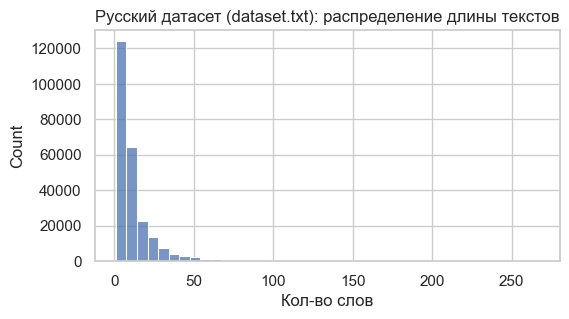


Распределение меток:


labels
NORMAL       203685
INSULT        36826
THREAT        12027
OBSCENITY      4261
Name: count, dtype: int64

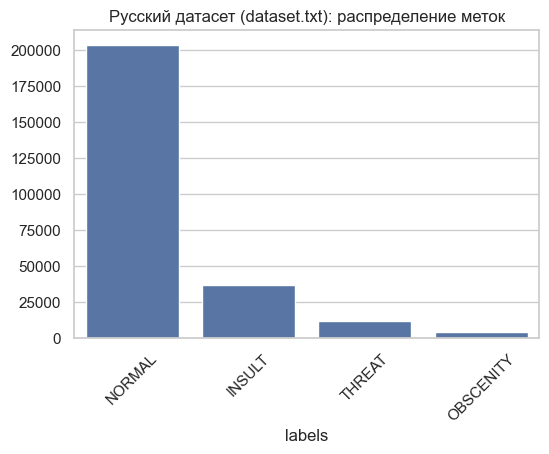


=== EDA: YouTube EN (raw) ===
Размер: (1000, 15)
Пустые тексты: 0
Средняя длина (слов): 33.78


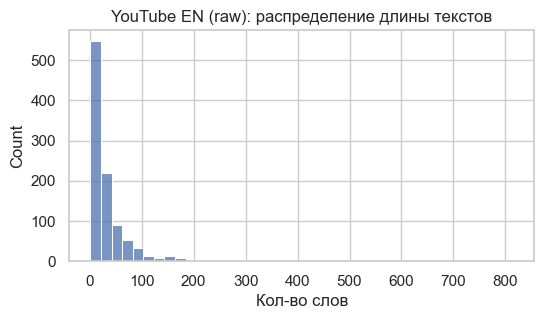


=== EDA: Toxic Comment EN (raw) ===
Размер: (159571, 7)
Пустые тексты: 0
Средняя длина (слов): 67.27


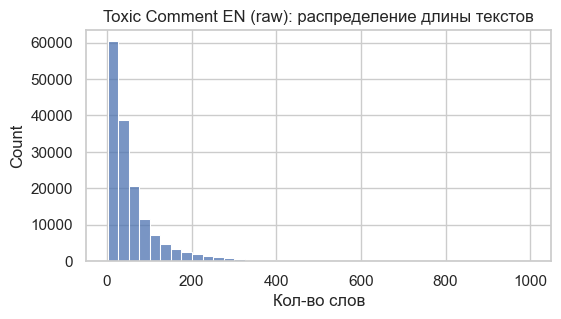

toxic      1111011000000000000000001101111100110010100000...
obscene    0010010000000000000000000101011100110010000000...
insult     0010011000000000000000000101010100110010000000...
threat     0000000000000000000000000000010000000000000000...
dtype: object


In [ ]:
run_text_eda(
    df=df_rus,
    text_col="text",
    label_col="labels",
    title="Русский датасет (dataset.txt)"
)

run_text_eda(
    df=df_yt_raw,
    text_col="Text",
    title="YouTube EN (raw)"
)
bool_cols = [c for c in df_yt_raw.columns if c.startswith("Is")]
df_yt_raw[bool_cols].sum().sort_values(ascending=False)

run_text_eda(
    df=df_toxic_raw,
    text_col="comment_text",
    title="Toxic Comment EN (raw)"
)
label_cols = ["toxic","obscene","insult","threat"]
print(df_toxic_raw[label_cols].sum())

В разверточном анализе видно, что в исходном датасете сильный дисбаланс по распределению меток. Этим обосновано использование дополнительных датасетов. Если данных их этих датасетов будет недостаточно - прибегнем в оверсэмплингу и даунсэмплингу.

Чтобы научить модели более корректно рассматривать оскорбления и подтекст, мы добавим словарь русского мата.

**Загружаем словарь матов**

In [ ]:
print("\nЗагружаем словарь матов...")

SWEAR_CACHE = "swear_words_clean.pkl"

swear_df = pd.DataFrame(columns=["text_clean", "labels", "source"])

try:
    # Загрузка датасета
    ds = load_dataset("ilyaxin/Russian-Swear-Words", split="train")

    print("Размер датасета:", len(ds))

    # Посмотрим первые 5 строк
    first_five = ds.select(range(5))
    for item in first_five:
        print(item)
except Exception as e:
    print("Ошибка загрузки словаря:", e)


Загружаем словарь матов...
Размер датасета: 403
{'word': 'блядь ', 'definition': 'Публичная женщина, проститутка; вообще распутная женщина. Обман, mendacium, — Блядь бо есть то и лжа.... Вздор, пустяки, deliramentum, nugae: Cмех то и блядь!, Их же (язычников) — бляди мне вся жертвы!, Кощюнные бляди, Притча то суть и блядь — Козм. пресв. о ерес. Да не почитають первосписаных блядии и кощюнь но истинное да почитають о Хѣ (Христе) Гѣ (Господе) нашем. Муч. Кир. Ул.. Обманщик, fallax: Молъвящим же людем на Иоанна и глющим (глаголющим?) йако блядь есть. Прох. Жит. Iо. Богосл. XLII.. Безумный, insanus: Умри, блядь, умри!. Прелюбодейка, meretrix: Аще кто зовётъ чюжую жену блядью..., Церк. Уст. Яросл. Любодейка Во множ.числе, — бляди, блядей; в старинном языке — злохуление, поносительныя речи Ложь, обман В нынешнем языке: непотребная женщина, блудница Болтун, пустомеля Пустая болтовня, неразумно мовленне Заблуждение, ересь, — blud Распутство, разврат Распутная женщина Ложь, обман Ересь, лжеуче

Структура датасета проста. Нам нужен только столбец "word". Все ругательства пометим как INSULT и добавим к финальному датасету позже. Предварительно выполним чистку и приведем датасет к общей структуре.

In [ ]:
# Берём только колонку word (без definition)
# сразу в pandas (экономим память)
words = pd.Series(ds["word"], dtype="string")

# Очистка
words = (
    words
    .dropna()
    .str.strip()
    .str.lower()
    .map(demask_text)
    .map(clean_minimal)
)

# убираем пустые и дубликаты
words = words[words.str.len() > 0].drop_duplicates().reset_index(drop=True)

print("Уникальных токенов:", len(words))

# Формирование DataFrame

swear_df = pd.DataFrame({
    "text_clean": words.values,
    "labels": [["INSULT"]] * len(words),
    "source": "swear_dict"
})

# Сохранение
joblib.dump(swear_df, SWEAR_CACHE)
print("Сохранено:", SWEAR_CACHE)

print("Форма:", swear_df.shape)

# Чистим память
del words, ds
gc.collect()

Уникальных токенов: 398
Сохранено: swear_words_clean.pkl
Форма: (398, 3)


541

In [ ]:
# Смотрим результат
swear_df.head(5)

,text_clean,labels,source
0,блядь,[INSULT],swear_dict
1,ебать,[INSULT],swear_dict
2,хуй,[INSULT],swear_dict
3,беспиздая,[INSULT],swear_dict
4,бля,[INSULT],swear_dict


# Предварительная обработка английских датасетов

Перед переводом датасетов, нужно их обработать.

Этот блок выполняет нормализацию англоязычных датасетов: приводит бинарные метки к логическому типу, адаптивно находит текстовые поля и восстанавливает замаскированную токсичность. Это критично для корректного перевода и обучения, иначе модель теряет значительную часть токсичного сигнала.

**Обработка reihanenamdari/youtube-toxicity-data**

In [ ]:
if not df_yt_raw.empty:
    bool_cols = [
        "IsToxic","IsAbusive","IsThreat","IsProvocative","IsObscene",
        "IsHatespeech","IsRacist","IsNationalist","IsSexist",
        "IsHomophobic","IsReligiousHate","IsRadicalism"
    ]

    # Нормализация типов:
    # True - "True"
    # False - "False"
    # NaN - "nan"
    for c in bool_cols:
        if c in df_yt_raw.columns:
            df_yt_raw[c] = (
                df_yt_raw[c]
                .astype(str)
                .str.upper()
                .astype(str).str.lower().map({
                    "true": True,
                    "false": False,
                    "1": True,
                    "0": False
                })
                .fillna(False)
            )
        else:
            df_yt_raw[c] = False

    # Нормализуем имя столбца. Это нужно, чтобы дальше весь пайплайн знал одно имя.
    if "Text" not in df_yt_raw.columns:
        cand = [c for c in df_yt_raw.columns if "text" in c.lower()]
        if cand:
            df_yt_raw.rename(columns={cand[0]: "Text"}, inplace=True)

    # Очистка текста и демаскировка
    df_yt_raw["Text"] = (
        df_yt_raw["Text"]
        .astype(str)
        .apply(demask_text)
    )

**Обработка jahangirhussen/toxic-comment**

In [ ]:
if not df_toxic_raw.empty:
    # Удаляем нерелевантный класс
    if "identity_hate" in df_toxic_raw.columns:
        df_toxic_raw = df_toxic_raw.drop(columns=["identity_hate"])
    # Нормализация имени текстового столбца во избежание конфликтов
    if "comment_text" not in df_toxic_raw.columns:
        cands = [c for c in df_toxic_raw.columns if "comment" in c.lower()]
        if cands:
            df_toxic_raw.rename(columns={cands[0]:"comment_text"}, inplace=True)

    # Очистка текста и демаскировка
    df_toxic_raw['comment_text'] = df_toxic_raw['comment_text'].astype(str)
    df_toxic_raw['comment_text'] = df_toxic_raw['comment_text'].apply(demask_text)

**Фильтруем англоязычные наборы данных перед переводом**

Переводить миллионы «обычных» комментариев - бессмысленно и вредно. Этот код фильтрует англоязычные датасеты до перевода, оставляя только токсичные и потенциально токсичные комментарии.
Это позволит нам сильно ускорить перевод, сократить потребление GPU/VRAM, не загрязнять датасет нерелевантными NORMAL-фразами, таким образом повысить качество обучения моделей.


In [ ]:
print("\nФильтруем англоязычные наборы данных перед переводом...")

# reihanenamdari/youtube-toxicity-data
df_yt_filtered = pd.DataFrame()
if not df_yt_raw.empty:
    # Определяем полезные строки, игнорирурем IsNormal для баланса.
    # Если хотя бы одно True, то строка полезна
    def yt_useful_row(r):
        return (r.get("IsThreat",False)==True) or (r.get("IsObscene",False)==True) or any(r.get(c,False)==True for c in ["IsToxic","IsRacist","IsNationalist","IsHomophobic","IsReligiousHate"])
    # Фильтрация. Оставляем только True.
    df_yt_filtered = df_yt_raw[df_yt_raw.apply(yt_useful_row, axis=1)].reset_index(drop=True)
    print("YT полезные строки:", len(df_yt_filtered))

# jahangirhussen/toxic-comment
df_toxic_filtered = pd.DataFrame()
if not df_toxic_raw.empty:
    def toxic_useful_row(r):
        for fld in ["toxic","obscene","insult","threat","severe_toxic","identity_hate"]:
            if fld in r.index and str(r[fld]).strip() in ["1","True","TRUE","true"]:
                return True
        return False
    df_toxic_filtered = df_toxic_raw[df_toxic_raw.apply(toxic_useful_row, axis=1)].reset_index(drop=True)
    print("toxic полезные строки:", len(df_toxic_filtered))


Фильтруем англоязычные наборы данных перед переводом...
YT полезные строки: 462
toxic полезные строки: 16171


# 4. Блок перевода

**Перевод отфильтрованных англоязычных наборов данных**

Для кеша используем формат parquet. Он компактный, быстрый и сохраняет типы данных.

In [ ]:
print("\nПеревод отфильтрованных англоязычных наборов данных. Если кэши существуют, загрузите их для экономии времени.")

# reihanenamdari/youtube-toxicity-data

if not df_yt_filtered.empty:

    # Проверка готового датасет-кэша
    if os.path.exists(YT_TRANSL_CACHE):
        df_yt_trans = pd.read_parquet(YT_TRANSL_CACHE)

        # Защита от старых кэшей
        if "text_clean" not in df_yt_trans.columns:
            df_yt_trans["text_clean"] = (
                df_yt_trans
                .get("text_ru", df_yt_trans.get("Text", ""))
                .astype(str)
                .apply(clean_minimal)
            )

    else:
        # Подготовка текстов
        texts = (
            df_yt_filtered["Text"]
            .fillna("")
            .astype(str)
            .tolist()
        )

        # Перевод (fp16 + NLLB внутри translate_texts_safe)
        translated = translate_texts_safe(
            texts,
            batch_size=64,                     # безопаснее для fp16
            max_length=TRANSLATION_MAX_TOKENS,
            n_workers=2,
            cache_file=TRANSLATION_CACHE       # ГЛОБАЛЬНЫЙ кэш
        )

        # Сборка датасета
        df_yt_trans = df_yt_filtered.copy().reset_index(drop=True)
        df_yt_trans["text_ru"] = translated
        df_yt_trans["text_clean"] = (
            df_yt_trans["text_ru"]
            .astype(str)
            .apply(clean_minimal)
        )

        # Сохранение готового датасета
        df_yt_trans.to_parquet(YT_TRANSL_CACHE, index=False)
        print("Перевод YT сохранен в кеш ->", YT_TRANSL_CACHE)

else:
    df_yt_trans = pd.DataFrame()


# jahangirhussen/toxic-comment

if not df_toxic_filtered.empty:

    # Проверка готового датасет-кэша
    if os.path.exists(TOXIC_TRANSL_CACHE):
        df_toxic_trans = pd.read_parquet(TOXIC_TRANSL_CACHE)

        if "text_clean" not in df_toxic_trans.columns:
            df_toxic_trans["text_clean"] = (
                df_toxic_trans
                .get("text_ru", df_toxic_trans.get("comment_text", ""))
                .astype(str)
                .apply(clean_minimal)
            )

    else:
        # Подготовка текстов
        texts = (
            df_toxic_filtered["comment_text"]
            .fillna("")
            .astype(str)
            .tolist()
        )

        # Перевод
        translated = translate_texts_safe(
            texts,
            batch_size=64,
            max_length=TRANSLATION_MAX_TOKENS,
            n_workers=2,
            cache_file=TRANSLATION_CACHE       # ГЛОБАЛЬНЫЙ кэш
        )

        # Сборка датасета
        df_toxic_trans = df_toxic_filtered.copy().reset_index(drop=True)
        df_toxic_trans["text_ru"] = translated
        df_toxic_trans["text_clean"] = (
            df_toxic_trans["text_ru"]
            .astype(str)
            .apply(clean_minimal)
        )

        # Сохранение
        df_toxic_trans.to_parquet(TOXIC_TRANSL_CACHE, index=False)
        print("Перевод toxic сохранен в кеш ->", TOXIC_TRANSL_CACHE)

else:
    df_toxic_trans = pd.DataFrame()


Перевод отфильтрованных англоязычных наборов данных. Если кэши существуют, загрузите их для экономии времени.


**Проверим результат**

In [ ]:
translated_yt = pd.read_parquet("yt_translated_ru.parquet")
translated_toxic = pd.read_parquet("toxic_translated_ru.parquet")
translated_cache = pd.read_parquet("translation_cache.parquet")

print("\nYOUTUBE")
translated_yt.head(5)


YOUTUBE


,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism,text_ru,text_clean
0,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement is not trained to shoot to app...,True,True,False,False,False,False,False,False,False,False,False,False,"Правоохранительные органы не обучены стрелять,...","правоохранительные органы не обучены стрелять,..."
1,Ugg3dWTOxryFfHgCoAEC,04kJtp6pVXI,\nDont you reckon them 'black lives matter' ba...,True,True,False,False,True,False,False,False,False,False,False,False,"Не считаете ли вы, что плакаты ""черные жизни и...","не считаете ли вы, что плакаты ""черные жизни и..."
2,Ugg9a6FtoXdxmXgCoAEC,04kJtp6pVXI,here people his facebook is https://ww.faceboo...,True,False,False,False,False,True,False,False,False,False,True,False,Вот люди его фейсбук https://www.facebook.com/...,вот люди его фейсбук у него есть связи с игил ...
3,Ugga9KzkNDGvlXgCoAEC,04kJtp6pVXI,"Check out this you tube post. ""Black man goes ...",True,False,False,False,False,True,True,False,False,False,False,False,"""Чёрный человек выступает против бунтовщиков Ф...","""чёрный человек выступает против бунтовщиков ф..."
4,UggBlIXoph7p-3gCoAEC,04kJtp6pVXI,I would LOVE to see this pussy go to Staten Is...,True,True,False,False,True,True,True,False,False,False,False,False,"Я бы очень хотел, чтобы эта кукла пошла на Ста...","я бы очень хотел, чтобы эта кукла пошла на ста..."


In [ ]:
print("\nTOXIC")
translated_toxic.head(5)


TOXIC


,comment_text,toxic,severe_toxic,obscene,threat,insult,text_ru,text_clean
0,!\n\nI won't stop! LOCK IT UP AHOLE,1,0,0,0,0,Я не останавливаюсь!,я не останавливаюсь!
1,"!\n\nIt is now inside your bones, your head. H...",1,0,0,0,0,"Он сейчас в твоих костях, в твоей голове, прес...","он сейчас в твоих костях, в твоей голове, прес..."
2,!\n\nSuck my DIHCK! Nihgga!\n\nYou don't want ...,1,1,1,0,1,"Нигга, ты не хочешь, чтобы люди узнали правду ...","нигга, ты не хочешь, чтобы люди узнали правду ..."
3,!\n\nWHY DOESN'T ANYONE BAN ME \n\nBAN ME BAN ...,1,0,0,0,0,Почему никто меня не запрещает?,почему никто меня не запрещает?
4,!\nWant to explain to me why you can revert yo...,1,0,1,0,1,"Хочешь объяснить мне, почему ты можешь перевер...","хочешь объяснить мне, почему ты можешь перевер..."


In [ ]:
print("\nCACHE")
translated_cache.head(5)


CACHE


,original,translated
0,Law enforcement is not trained to shoot to app...,"Правоохранительные органы не обучены стрелять,..."
1,\nDont you reckon them 'black lives matter' ba...,"Не считаете ли вы, что плакаты ""черные жизни и..."
2,here people his facebook is https://ww.faceboo...,Вот люди его фейсбук https://www.facebook.com/...
3,"Check out this you tube post. ""Black man goes ...","""Чёрный человек выступает против бунтовщиков Ф..."
4,I would LOVE to see this pussy go to Staten Is...,"Я бы очень хотел, чтобы эта кукла пошла на Ста..."


**Формируем метки для переведенных данных**

Это ключевой блок, где «сырые переводы» превращаются в обучающие примеры для мультиметочной классификации.

Мы приводим разнородные датасеты к единой системе мультиметок, отбрасывая строки без релевантных классов и явно сохраняя источник данных. Это позволяет корректно объединять корпуса и контролировать вклад каждого источника в обучение.

Распределим метки англоязычных датасетов:

**1. reihanenamdari/youtube-toxicity-data**

IsNormal - игнорируем (NORMAL сильно доминирует)

IsThreat - THREAT

IsObscene - OBSCENITY

Остальное:
IsToxic IsAbusive IsProvocative IsHatespeech IsRacist
IsNationalist IsSexist IsHomophobic IsReligiousHate - INSULT

Это вербальная агрессия, не мат и не прямая угроза
значит семантически ближе к INSULT

**2. jahangirhussen/toxic-comment**

threat - THREAT

obscene - OBSCENITY

Остальное:
toxic, insult, severe_toxic, identity_hate - INSULT

In [ ]:
# reihanenamdari/youtube-toxicity-data
# Защита пайплайна. Если датасет не был загружен или отфильтрован в 0 строк, код не упадёт
if not df_yt_trans.empty:
    print("df_yt_trans size:", len(df_yt_trans))
    # Ремаппим метки на наши.
    df_yt_trans['labels'] = df_yt_trans.apply(yt_labels, axis=1)
    # Отбрасываем пустые метки, если таковые прошли фильтрацию или потеряли флаг при чистке
    df_yt_used = df_yt_trans[df_yt_trans['labels'].map(lambda L: len(L)>0)].copy()
    # Маркируем источник данных
    df_yt_used['source'] = 'youtube_en_translated'
else:
    df_yt_used = pd.DataFrame()

# jahangirhussen/toxic-comment
if not df_toxic_trans.empty:
    df_toxic_trans['labels'] = df_toxic_trans.apply(toxic_labels, axis=1)
    df_toxic_used = df_toxic_trans[df_toxic_trans['labels'].map(lambda L: len(L)>0)].copy()
    df_toxic_used['source'] = 'toxic_en_translated'
else:
    df_toxic_used = pd.DataFrame()

df_yt_trans size: 462


In [ ]:
df_yt_used.head(5)

,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism,text_ru,text_clean,labels,source
0,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement is not trained to shoot to app...,True,True,False,False,False,False,False,False,False,False,False,False,"Правоохранительные органы не обучены стрелять,...","правоохранительные органы не обучены стрелять,...",[INSULT],youtube_en_translated
1,Ugg3dWTOxryFfHgCoAEC,04kJtp6pVXI,\nDont you reckon them 'black lives matter' ba...,True,True,False,False,True,False,False,False,False,False,False,False,"Не считаете ли вы, что плакаты ""черные жизни и...","не считаете ли вы, что плакаты ""черные жизни и...","[OBSCENITY, INSULT]",youtube_en_translated
2,Ugg9a6FtoXdxmXgCoAEC,04kJtp6pVXI,here people his facebook is https://ww.faceboo...,True,False,False,False,False,True,False,False,False,False,True,False,Вот люди его фейсбук https://www.facebook.com/...,вот люди его фейсбук у него есть связи с игил ...,[INSULT],youtube_en_translated
3,Ugga9KzkNDGvlXgCoAEC,04kJtp6pVXI,"Check out this you tube post. ""Black man goes ...",True,False,False,False,False,True,True,False,False,False,False,False,"""Чёрный человек выступает против бунтовщиков Ф...","""чёрный человек выступает против бунтовщиков ф...",[INSULT],youtube_en_translated
4,UggBlIXoph7p-3gCoAEC,04kJtp6pVXI,I would LOVE to see this pussy go to Staten Is...,True,True,False,False,True,True,True,False,False,False,False,False,"Я бы очень хотел, чтобы эта кукла пошла на Ста...","я бы очень хотел, чтобы эта кукла пошла на ста...","[OBSCENITY, INSULT]",youtube_en_translated


In [ ]:
df_toxic_used.head(5)

,comment_text,toxic,severe_toxic,obscene,threat,insult,text_ru,text_clean,labels,source
0,!\n\nI won't stop! LOCK IT UP AHOLE,1,0,0,0,0,Я не останавливаюсь!,я не останавливаюсь!,[INSULT],toxic_en_translated
1,"!\n\nIt is now inside your bones, your head. H...",1,0,0,0,0,"Он сейчас в твоих костях, в твоей голове, прес...","он сейчас в твоих костях, в твоей голове, прес...",[INSULT],toxic_en_translated
2,!\n\nSuck my DIHCK! Nihgga!\n\nYou don't want ...,1,1,1,0,1,"Нигга, ты не хочешь, чтобы люди узнали правду ...","нигга, ты не хочешь, чтобы люди узнали правду ...","[INSULT, OBSCENITY]",toxic_en_translated
3,!\n\nWHY DOESN'T ANYONE BAN ME \n\nBAN ME BAN ...,1,0,0,0,0,Почему никто меня не запрещает?,почему никто меня не запрещает?,[INSULT],toxic_en_translated
4,!\nWant to explain to me why you can revert yo...,1,0,1,0,1,"Хочешь объяснить мне, почему ты можешь перевер...","хочешь объяснить мне, почему ты можешь перевер...","[INSULT, OBSCENITY]",toxic_en_translated


**Объединение всех источников**

Это ключевой этап сборки финального датасета. Здесь мы аккуратно объединяем все источники данных в единый корпус, приводим формат к одному стандарту и добавляем служебные признаки для анализа и балансировки.

In [ ]:
# Создание списка фреймов
frames = [df_rus[['text_clean','labels','source']].copy()]

# Условное добавление переведённых данных
if not df_yt_used.empty:
    frames.append(df_yt_used[['text_clean','labels','source']])
if not df_toxic_used.empty:
    frames.append(df_toxic_used[['text_clean','labels','source']])
# Добавление синтетических данных (мат)
if not swear_df.empty:
    frames.append(swear_df[['text_clean','labels','source']])

# Объединение всех источников и перемешивание данных
df_full = pd.concat(frames, ignore_index=True).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
# Нормализация формата меток
df_full['labels'] = df_full['labels'].apply(lambda L: list(L) if isinstance(L,(list,tuple)) else [L])
# Количество меток
df_full['label_count'] = df_full['labels'].apply(len)
# Длина текста (в словах)
df_full['word_count'] = df_full['text_clean'].apply(lambda s: len(str(s).split()))
print('Строк после объединения:', len(df_full))

Строк после объединения: 265321


In [ ]:
df_full.tail(15)

,text_clean,labels,source,label_count,word_count
265306,"иди, трахнись, пока она не упадет.","[INSULT, OBSCENITY]",toxic_en_translated,2,6
265307,зачем трусы то снял?)),[NORMAL],ru_original,1,4
265308,пипец игруха виснет. можно литряк заглотить по...,[NORMAL],ru_original,1,11
265309,убился мультом (sr),[NORMAL],ru_original,1,3
265310,"что, вроде норм",[NORMAL],ru_original,1,3
265311,какой хороший друг - всегда при тебе...,[NORMAL],ru_original,1,7
265312,обожаю его просто супер!,[NORMAL],ru_original,1,4
265313,люди не проходите мимо не буте жестоки🌹,[NORMAL],ru_original,1,7
265314,сбербанк онлайн чек по операции онлайн сбербан...,[NORMAL],ru_original,1,58
265315,"войска китая,войска нато уже в хабаровске.",[NORMAL],ru_original,1,6


# 5. Финальная обработка перед обучением

Тут мы проведем разверточный анализ (EDA) финальных данных, балансировку через оверсэмплинг и обрезку. Так же для наглядности визуализируем результаты.

**EDA перед балансировкой**


EDA перед балансировкой:

=== EDA: Финальный датасет (до балансировки) ===
Размер: (265321, 5)
Пустые тексты: 3
Средняя длина (слов): 13.16


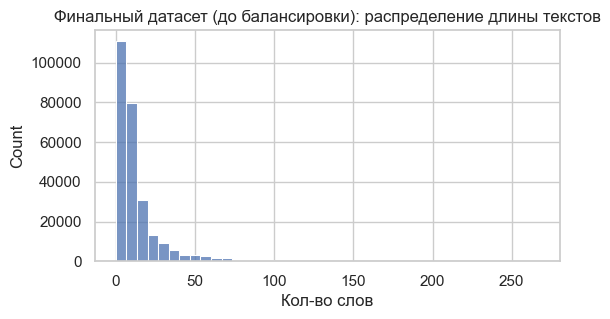


Распределение меток:


labels
NORMAL       203685
INSULT        53513
OBSCENITY     12810
THREAT        12526
Name: count, dtype: int64

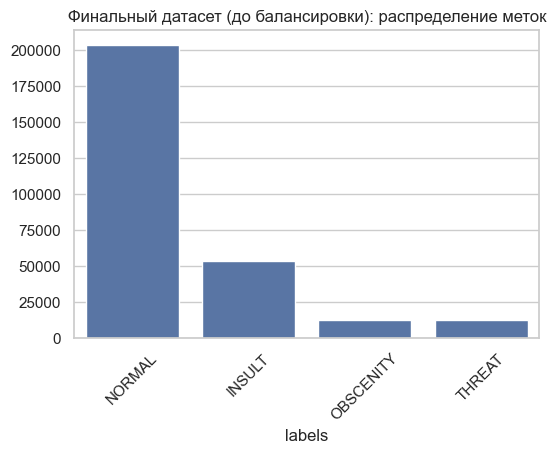

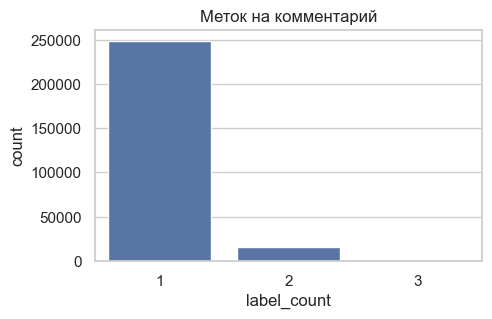

In [ ]:
print('\nEDA перед балансировкой:')

run_text_eda(
    df=df_full,
    text_col="text_clean",
    label_col="labels",
    title="Финальный датасет (до балансировки)"
)

# Сколько меток у одного комментария
plt.figure(figsize=(5,3)); sns.countplot(x=df_full['label_count']); plt.title('Меток на комментарий'); plt.show()

В рамках EDA мы проанализировали распределение меток, длину текстов и долю мультиметочных примеров. Это позволило выявить сильный перекос в сторону NORMAL, наличие маскированной токсичной лексики и редкость метки THREAT. На основании этих наблюдений были приняты решения об уменьшении NORMAL примеров и обучении отдельных бинарных классификаторов с индивидуальными порогами.

**Балансировка**

В данном блоке реализована умеренная стратегия балансировки данных. Мы усиливаем редкие токсичные классы путём оверсэмплинга, при этом ограничиваем доминирующий класс NORMAL, предварительно удаляя короткие нерелевантные комментарии. Такой подход позволяет сохранить реалистичное распределение данных, избежать переобучения и обеспечить стабильное обучение моделей для всех меток.

COMBINED_CSV не найден. Создаём датасет с нуля

Применяем oversampling / downsampling...
Исходный размер датасета: (265321, 5)
Распределение меток до балансировки:
labels
NORMAL       203685
INSULT        53513
OBSCENITY     12810
THREAT        12526
Name: count, dtype: int64

Разделение выполнено:
  NORMAL:        203685
  INSULT only:   36851
  INSULT multi:  16662
  THREAT:        12526
  OBSCENITY:     12810

После ограничения NORMAL:
  NORMAL: 100000

Размер финального датасета: (247311, 5)
Распределение меток после балансировки:
labels
INSULT       109050
NORMAL       100000
OBSCENITY     89310
THREAT        60380
Name: count, dtype: int64

=== EDA: Финальный датасет (после балансировки) ===
Размер: (247305, 5)
Пустые тексты: 0
Средняя длина (слов): 14.83


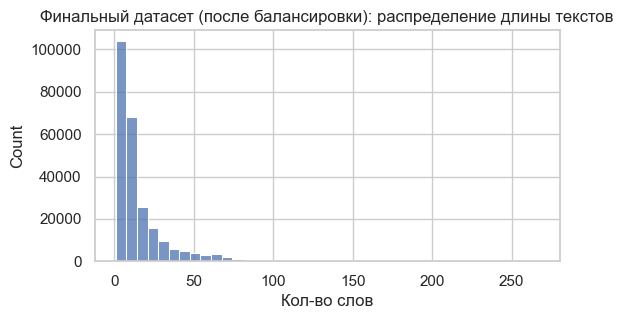


Распределение меток:


labels
INSULT       109044
NORMAL       100000
OBSCENITY     89304
THREAT        60380
Name: count, dtype: int64

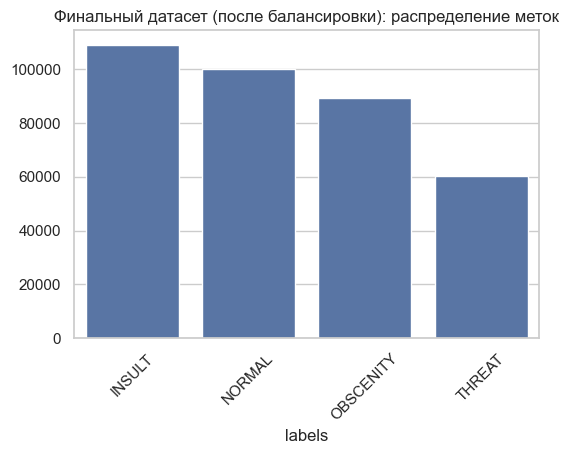

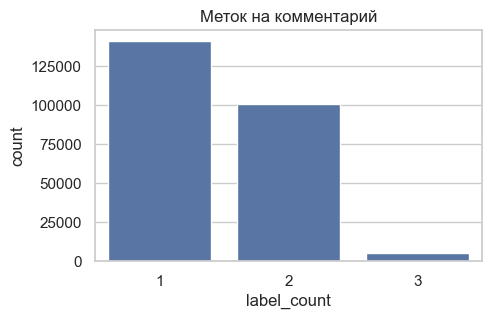


Сохраняем итоговый датасет...
Итоговый датасет сохранён: combined_dataset.csv
Итоговый датасет сохранён также в parquet: combined_dataset.parquet

Combined dataset готов к использованию
Строк: 247305
Столбцы: ['text_clean', 'labels']


,text_clean,labels
138131,хорошо это вода,[NORMAL]
211071,"к сожалению, у меня нет лекарства от глупости....",[INSULT]
142361,shutup [[who u think u is you gay nobody that'...,"[INSULT, OBSCENITY]"
86573,этих тварей нужно стрелять.,"[INSULT, THREAT]"
140846,полно хватало наглых и прохиндеев.,[NORMAL]


In [ ]:
# На выходе всегда есть DataFrame с колонками:
#   - text_clean
#   - labels

COMBINED_CSV = "combined_dataset.csv"
COMBINED_PARQUET = "combined_dataset.parquet"

if os.path.exists(COMBINED_CSV):
    print(f"Найден кеш датасета: {COMBINED_CSV}")
    df = pd.read_csv(COMBINED_CSV)
    df["text_clean"] = df["text_clean"].astype(str)
    df["labels"] = df["labels"].apply(lambda x: eval(x) if isinstance(x, str) else x)

    print("Форма датасета:", df.shape)
    display(df.sample(3, random_state=RANDOM_STATE))

else:
    print("COMBINED_CSV не найден. Создаём датасет с нуля")

    print("\nПрименяем oversampling / downsampling...")

    # Базовые проверки

    required_cols = {"text_clean", "labels", "word_count"}
    missing = required_cols - set(df_full.columns)
    if missing:
        raise ValueError(f"В df_full отсутствуют обязательные колонки: {missing}")

    print("Исходный размер датасета:", df_full.shape)
    print("Распределение меток до балансировки:")
    print(df_full["labels"].explode().value_counts())

    # Разделяем датасет по типам:

    # Только NORMAL
    df_normals = df_full[df_full["labels"].apply(lambda L: L == ["NORMAL"])].copy()

    # Только INSULT
    df_insult_only = df_full[df_full["labels"].apply(lambda L: L == ["INSULT"])].copy()

    # Мультиметки с INSULT
    df_insult_multi = df_full[
        df_full["labels"].apply(lambda L: "INSULT" in L and L != ["INSULT"])
    ].copy()

    # Все THREAT (включая мультиметки)
    df_threat = df_full[df_full["labels"].apply(lambda L: "THREAT" in L)].copy()

    # Все OBSCENITY (включая мультиметки)
    df_obscene = df_full[df_full["labels"].apply(lambda L: "OBSCENITY" in L)].copy()

    print("\nРазделение выполнено:")
    print(f"  NORMAL:        {len(df_normals)}")
    print(f"  INSULT only:   {len(df_insult_only)}")
    print(f"  INSULT multi:  {len(df_insult_multi)}")
    print(f"  THREAT:        {len(df_threat)}")
    print(f"  OBSCENITY:     {len(df_obscene)}")


    # Балансировка

    # INSULT-only:
    if MULT_INSULT < 1.0:
        df_insult_only_bal = downsample_df(df_insult_only, MULT_INSULT)
    else:
        df_insult_only_bal = upsample_df(df_insult_only, MULT_INSULT)

    # THREAT
    if MULT_THREAT < 1.0:
        df_threat_up = downsample_df(df_threat, MULT_THREAT)
    else:
        df_threat_up = upsample_df(df_threat, MULT_THREAT)

    # OBSCENITY
    if MULT_OBSCENITY < 1.0:
        df_obscene_up = downsample_df(df_obscene, MULT_OBSCENITY)
    else:
        df_obscene_up = upsample_df(df_obscene, MULT_OBSCENITY)

    # Ограничение NORMAL

    # Убираем слишком короткие NORMAL
    df_normals = df_normals[df_normals["word_count"] >= 3].copy()

    # Ограничение сверху, чтобы NORMAL не доминировал
    MAX_NORMALS = max(100_000, len(df_insult_only_bal))
    if len(df_normals) > MAX_NORMALS:
        df_normals = df_normals.sample(n=MAX_NORMALS, random_state=RANDOM_STATE)

    print("\nПосле ограничения NORMAL:")
    print(f"  NORMAL: {len(df_normals)}")


    # Финальная сборка

    frames_bal = [
        df_normals,
        df_insult_only_bal,
        df_insult_multi,    # мультиметки сохраняем всегда
        df_threat_up,
        df_obscene_up
    ]

    df_balanced = (
        pd.concat(frames_bal, ignore_index=True)
          .sample(frac=1, random_state=RANDOM_STATE)
          .reset_index(drop=True)
    )

    print("\nРазмер финального датасета:", df_balanced.shape)
    print("Распределение меток после балансировки:")
    print(df_balanced["labels"].explode().value_counts())


    # КОНТРОЛЬ И СЛУЖЕБНЫЕ ПОЛЯ

    # Число меток у одного объекта
    df_balanced["label_count"] = df_balanced["labels"].apply(len)

    # Защита от пустых текстов
    df_balanced = df_balanced[
        df_balanced["text_clean"].notna() &
        (df_balanced["text_clean"].str.len() > 0)
    ].reset_index(drop=True)

    # EDA
    run_text_eda(
        df=df_balanced,
        text_col="text_clean",
        label_col="labels",
        title="Финальный датасет (после балансировки)"
    )

    plt.figure(figsize=(5, 3))
    sns.countplot(x=df_balanced["label_count"])
    plt.title("Меток на комментарий")
    plt.show()


    # СОХРАНЕНИЕ COMBINED_CSV
    # Оставляем ТОЛЬКО text_clean и labels
    print("\nСохраняем итоговый датасет...")

    df_final = df_balanced[["text_clean", "labels"]].copy()

    df_final.to_csv(COMBINED_CSV, index=False)
    print(f"Итоговый датасет сохранён: {COMBINED_CSV}")

    df_final.to_parquet(COMBINED_PARQUET, index=False)
    print(f"Итоговый датасет сохранён также в parquet: {COMBINED_PARQUET}")

    # Загружаем в df для дальнейших шагов
    df = df_final.copy()


# ЖЁСТКАЯ ВАЛИДАЦИЯ

required_cols = {"text_clean", "labels"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"В combined_dataset отсутствуют обязательные колонки: {missing}")

df["text_clean"] = df["text_clean"].astype(str)
df["labels"] = df["labels"].apply(lambda x: list(x) if isinstance(x, (list, tuple, set)) else x)

print("\nCombined dataset готов к использованию")
print("Строк:", len(df))
print("Столбцы:", df.columns.tolist())
display(df.sample(5, random_state=RANDOM_STATE))

# **Выводы по финальному датасету:**

**Размер датасета:** 247 305 комментариев

**Пустые тексты:** 0

**Средняя длина комментария:** 14.83 слова. Большинство комментариев до 20 слов. Длинные тексты встречаются редко. Распределение имеет длинный хвост. Это типичное поведение для реальных комментариев.

**Значит данные успешно очищены, пустые строки удалены.**

Классы стали намного более сбалансированы, чем в исходных данных. Разрыв между классами уменьшился, редкие классы увеличены через объединение датасетов и upsampling. В особенности THREAT значительно увеличен, OBSCENITY также усилен,
NORMAL ограничен до 100.000 комментариев, во избежание предвзятости модели (токсичные комментарии часто получали метку NORMAL или мультиметку INSULT+NORMAL).

Большинство комментариев имеют одну метку. Довольно много двойных меток, тройные метки редкие. Это норма для мультиметочной токсичности. **Таким образом, у нас достаточно данных, чтобы модели учились распознавать комбинации меток.**

# 6. Обучение моделей

**Подготовка X/Y и сплиты**

Этот блок преобразует метки в машинно-обучаемый формат. Мы готовим входные признаки (X) и целевые переменные (Y). После этого корректно делим данные на Train / Validation / Test.

Такой подход сохраняет баланс и сложность примеров при разбиении.

Иными словами, этот код подготавливает данные к корректному обучению и честной оценке модели.

На входе датафрейм с колонками: text_clean тип str, labels тип list[str].

На выходе: X_train, X_val, X_test тип list[str]  (или np.ndarray dtype=object), y_train, y_val, y_test тип np.ndarray (int8 / uint8).

mlb сохраним в кеш.

**MultiLabelBinarizer**

In [ ]:
MLB_PATH = "mlb.pkl"

print("\nMultiLabelBinarizer")

labels_list = df["labels"].tolist()   # list[list[str]]

if os.path.exists(MLB_PATH):
    print("mlb загружен из кеша")
    mlb = joblib.load(MLB_PATH)
    Y = mlb.transform(labels_list)
else:
    print("Обучаем mlb...")
    mlb = MultiLabelBinarizer()
    Y = mlb.fit_transform(labels_list)
    joblib.dump(mlb, MLB_PATH)
    print(f"mlb сохранён: {MLB_PATH}")

Y = Y.astype(np.uint8)   # экономим память

labels = list(mlb.classes_)
print("Классы:", labels)
print("Y shape:", Y.shape, "dtype:", Y.dtype)


MultiLabelBinarizer
Обучаем mlb...
mlb сохранён: mlb.pkl
Классы: ['INSULT', 'NORMAL', 'OBSCENITY', 'THREAT']
Y shape: (247305, 4) dtype: uint8


**Формирование X как python list, без pandas**

In [ ]:
print("\nФормирование X")

X = df["text_clean"].astype(str).tolist()
print(f"Размер X: {len(X)}")


Формирование X
Размер X: 247305


**Признак для стратификации**

In [ ]:
print("\nПодготовка стратификации")

# Количество активных меток на объект
label_count = np.array([len(x) for x in labels_list], dtype=np.int16)

unique, counts = np.unique(label_count, return_counts=True)
print("Распределение label_count:")
for u, c in zip(unique, counts):
    print(f"  {u:2d} = {c}")


Подготовка стратификации
Распределение label_count:
   1 = 141173
   2 = 100841
   3 = 5291


Теперь нужно сделать разделение на Train/Validation/Test.

**Train** служит для тренировки модели.

**Validation** нужен для настройки модели. Используется для подбора гиперпараметров, выбора лучшей модели, threshold и ансамбля. Поэтому его логично вырезать из Train.

**Test** используется для проверки обученной модели.

Для начала сделаем Train/Test split, чтобы сразу отделить Test. После этого из оставшегося Train отделим Validation. Такой подход защищает от утечек информации, а так же упрощает изменение размера Validation и использование Кросс-валидации (Cross-Validation). Это является практическим стандартом в ML.

Конечно не будет ошибкой сразу выполнить Train/Validation/Test split, но у нас сложный pipeline, в котором особенно важен контроль над Validation. Примерная схема такая:

In [ ]:
#FULL DATA
#   │
#   ├── Train (80%)
#   │      │
#   │      ├── Train_inner
#   │      └── Validation
#   │             │
#   │             ├── выбор модели
#   │             ├── выбор ансамбля
#   │             └── подбор threshold
#   │
#   └── Test (20%)
#          │
#          └── финальная проверка

**Train / Test split**

In [ ]:
print("\nTrain / Test split")

(
    X_train_full,
    X_test,
    y_train_full,
    y_test,
    lc_train_full,
    lc_test,
) = train_test_split(
    X,
    Y,
    label_count,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=label_count
)

print(f"Train_full: {len(X_train_full)}")
print(f"Test      : {len(X_test)}")


Train / Test split
Train_full: 197844
Test      : 49461


**Train / Validation split**

In [ ]:
print("\nTrain / Validation split")

train_label_counts = y_train_full.sum(axis=1).astype(np.int16)

(
    X_train,
    X_val,
    y_train,
    y_val,
) = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=train_label_counts
)

print(f"Train: {len(X_train)}")
print(f"Val  : {len(X_val)}")
print(f"Test : {len(X_test)}")


Train / Validation split
Train: 168167
Val  : 29677
Test : 49461


**Контроль баланса + фиксация генераторов**

Если мы хотим иметь возможность выполнять код с использованием данных из кеша, обязательно нужно фиксировать генераторы случайных чисел. Иначе при повторном исполнении мы получим совершенно другие результаты. Например, обучив модель на точность 98%, при повторном запуске метрики упадут в лучшем случае на треть.

In [ ]:
print("\nКонтроль баланса меток по сплитам:")

def print_label_stats(name, Y_split):
    counts = Y_split.sum(axis=0)
    print(f"\n{name}:")
    for lab, cnt in zip(labels, counts):
        print(f"  {lab:12s}: {int(cnt)}")

print_label_stats("TRAIN", y_train)
print_label_stats("VAL",   y_val)
print_label_stats("TEST",  y_test)

print("\nФиксация RANDOM_STATE")

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)

print("RANDOM_STATE зафиксирован")


Контроль баланса меток по сплитам:

TRAIN:
  INSULT      : 74145
  NORMAL      : 67987
  OBSCENITY   : 60751
  THREAT      : 41052

VAL:
  INSULT      : 13071
  NORMAL      : 12028
  OBSCENITY   : 10759
  THREAT      : 7190

TEST:
  INSULT      : 21828
  NORMAL      : 19985
  OBSCENITY   : 17794
  THREAT      : 12138

Фиксация RANDOM_STATE
RANDOM_STATE зафиксирован


**Чистка памяти и финальный контроль**

In [ ]:
# Чистка памяти

print("\n Освобождаем ОЗУ")

del df
del labels_list
del label_count
del lc_train_full, lc_test
del X_train_full, y_train_full
gc.collect()

# Финальный контроль

print("\nФинальный контроль размеров:")

print("X_train:", len(X_train))
print("X_val  :", len(X_val))
print("X_test :", len(X_test))

print("y_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)

assert len(X_train) == y_train.shape[0]
assert len(X_val)   == y_val.shape[0]
assert len(X_test)  == y_test.shape[0]


 Освобождаем ОЗУ

Финальный контроль размеров:
X_train: 168167
X_val  : 29677
X_test : 49461
y_train: (168167, 4)
y_val  : (29677, 4)
y_test : (49461, 4)


Теперь весь pipeline работает без pandas. X имеет тип list[str], Y - numpy uint8. Это позволит нам тратить меньше ОЗУ без потери качества.

**TF-IDF (word+char) и SVD**

Это центральный кусок всего пайплайна признаков. Превращает текст в числовые признаки. Захватывает семантику, морфологию и маскированные ругательства
. Готовит два представления:

***1. Разреженное (TF-IDF)*** — для деревьев и бустинга.

***TF-IDF (Term Frequency-Inverse Document Frequency)*** – это статистический метод оценки важности слова в документе относительно коллекции документов, который показывает, насколько слово уникально и значимо для конкретного текста. Он рассчитывается как произведение Частоты слова (TF), которая отражает количество вхождений слова в документе, и Обратной частоты документа (IDF), которая снижает вес часто употребляемых слов (предлогов, союзов), делая их менее значимыми.

***2. Плотное (SVD)*** — для линейных и нейросетевых моделей.

***Сингулярное разложение (Singular Value Decomposition, SVD)*** — декомпозиция вещественной матрицы с целью ее приведения к каноническому виду. Сингулярное разложение является удобным методом при работе с матрицами. Оно показывает геометрическую структуру матрицы и позволяет наглядно представить имеющиеся данные.

**Зачем нужен SVD**

TF-IDF разреженный и плохо подходит для алгоритмов SVM, MLP и логистики. SVD
сжимает пространство, сохраняет смысл и делает признаки плотными. Это Latent Semantic Analysis (LSA). Каждая модель работает в своём оптимальном пространстве.

Данное решение устойчиво к маскировке, эффективно по памяти, масштабируемо, даёт высокий recall и совместимо с кешированием.

**TF-IDF OBJECTS**

In [ ]:
print("\nTF-IDF objects")

if TFIDF_WORD_PATH.exists() and TFIDF_CHAR_PATH.exists():
    print("TF-IDF загружены из кеша")
    word_tfidf = joblib.load(TFIDF_WORD_PATH)
    char_tfidf = joblib.load(TFIDF_CHAR_PATH)
else:
    print("Обучаем TF-IDF...")
    word_tfidf = TfidfVectorizer(
        max_features=TFIDF_MAX_FEATURES,
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True,
        analyzer="word",
        dtype=np.float32
    )

    char_tfidf = TfidfVectorizer(
        max_features=CHAR_TFIDF_MAX,
        ngram_range=(3, 5),
        analyzer="char_wb",
        sublinear_tf=True,
        dtype=np.float32
    )

    t0 = time.time()
    word_tfidf.fit(X_train)
    char_tfidf.fit(X_train)
    print("Время TF-IDF fit:", round(time.time() - t0, 2), "sec")

    joblib.dump(word_tfidf, TFIDF_WORD_PATH)
    joblib.dump(char_tfidf, TFIDF_CHAR_PATH)
    print("TF-IDF сохранены")


TF-IDF objects
Обучаем TF-IDF...
Время TF-IDF fit: 22.58 sec
TF-IDF сохранены


**TF-IDF МАТРИЦЫ**

In [ ]:
print("\nTF-IDF Матрицы")

if X_TRAIN_TFIDF_PATH.exists():
    print("Sparse TF-IDF загружены")
    X_train_tfidf = sp.load_npz(X_TRAIN_TFIDF_PATH)
    X_val_tfidf   = sp.load_npz(X_VAL_TFIDF_PATH)
    X_test_tfidf  = sp.load_npz(X_TEST_TFIDF_PATH)
else:
    print("Строим sparse TF-IDF...")

    X_train_tfidf = sp.hstack([
        word_tfidf.transform(X_train),
        char_tfidf.transform(X_train)
    ], format="csr")

    X_val_tfidf = sp.hstack([
        word_tfidf.transform(X_val),
        char_tfidf.transform(X_val)
    ], format="csr")

    X_test_tfidf = sp.hstack([
        word_tfidf.transform(X_test),
        char_tfidf.transform(X_test)
    ], format="csr")

    sp.save_npz(X_TRAIN_TFIDF_PATH, X_train_tfidf)
    sp.save_npz(X_VAL_TFIDF_PATH,   X_val_tfidf)
    sp.save_npz(X_TEST_TFIDF_PATH,  X_test_tfidf)

    print("Sparse TF-IDF сохранены")


TF-IDF Матрицы
Строим sparse TF-IDF...
Sparse TF-IDF сохранены


**SVD OBJECT + МАТРИЦЫ**

In [ ]:
print("\nSVD object + Матрицы")

if SVD_PATH.exists():
    print("SVD загружен из кеша")
    svd = joblib.load(SVD_PATH)
else:
    print("Обучаем SVD...")
    svd = TruncatedSVD(
        n_components=SVD_COMPONENTS,
        random_state=RANDOM_STATE
    )
    t0 = time.time()
    svd.fit(X_train_tfidf)
    print("Время SVD fit:", round(time.time() - t0, 2), "sec")

    joblib.dump(svd, SVD_PATH)
    print("SVD сохранён")

# Приводим SVD к sparce и сохраняем в кеш. Если файл сущзествует, грузим.
X_train_svd = svd_transform_and_cache(X_train_tfidf, X_TRAIN_SVD_PATH, "train")
X_val_svd   = svd_transform_and_cache(X_val_tfidf,   X_VAL_SVD_PATH,   "val")
X_test_svd  = svd_transform_and_cache(X_test_tfidf,  X_TEST_SVD_PATH,  "test")


SVD object + Матрицы
Обучаем SVD...
Время SVD fit: 20.88 sec
SVD сохранён
Считаем train SVD...
train SVD сохранён
Считаем val SVD...
val SVD сохранён
Считаем test SVD...
test SVD сохранён


**META FEATURES**

In [ ]:
print("\nMETA features")

# Приводим к sparce и сохраняем в кеш. Если файл сущзествует, грузим.
meta_train = meta_to_sparse(X_train, META_TRAIN_PATH, "train")
meta_val   = meta_to_sparse(X_val,   META_VAL_PATH,   "val")
meta_test  = meta_to_sparse(X_test,  META_TEST_PATH,  "test")


META features
Считаем META train...
META train сохранены
Считаем META val...
META val сохранены
Считаем META test...
META test сохранены


**Финальные матрицы для моделей**

In [ ]:
print("\nФинальные матрицы для моделей")

# Для XGB и LGB  чистый разреженный TF-IDF
X_train_tfidf_lgb = X_train_tfidf
X_val_tfidf_lgb   = X_val_tfidf
X_test_tfidf_lgb  = X_test_tfidf

X_train_tfidf_xgb = X_train_tfidf
X_val_tfidf_xgb   = X_val_tfidf
X_test_tfidf_xgb  = X_test_tfidf

# Для SVC только SVD
X_train_svd_svc = X_train_svd
X_val_svd_svc   = X_val_svd
X_test_svd_svc  = X_test_svd

# Для MLP используем SVD + META
X_train_mlp = build_mlp_matrix(X_train_svd, meta_train, X_TRAIN_MLP_PATH, "train")
X_val_mlp   = build_mlp_matrix(X_val_svd,   meta_val,   X_VAL_MLP_PATH,   "val")
X_test_mlp  = build_mlp_matrix(X_test_svd,  meta_test,  X_TEST_MLP_PATH,  "test")


Финальные матрицы для моделей
Собираем MLP matrix train...
MLP matrix train сохранена
Собираем MLP matrix val...
MLP matrix val сохранена
Собираем MLP matrix test...
MLP matrix test сохранена


**Проверка согласованности и чистка памяти**

В RAM остаются только sparse матрицы. Ни одного DataFrame и dense матрицы. Стараемся максимально избежать утечки памяти.

In [ ]:
print("\n Проверка согласованности и чистка памяти")

assert X_train_tfidf.shape[0] == y_train.shape[0]
assert X_val_tfidf.shape[0]   == y_val.shape[0]
assert X_test_tfidf.shape[0]  == y_test.shape[0]

assert X_train_svd_svc.shape[0] == y_train.shape[0]
assert X_train_mlp.shape[0]     == y_train.shape[0]

print("Удаление промежуточных объектов")

del meta_train, meta_val, meta_test
gc.collect()


 Проверка согласованности и чистка памяти
Удаление промежуточных объектов


16133

**Обучение моделей пометочно**

Пробуем 4 метода и выбираем лучший по val F1

Методы: LightGBM, XGBoost, LinearSVC (на SVD), MLP (на SVD).

Весь процесс реализуем в цикле. Если модель уже обучена, будем грузить ее, иначе стартуем обучение и сохраняем модель в кеш. На каждую метку будем выбирать две лучшие модели и тестировать ансамбль из них. Часто ансамбли показывают F1 ниже соло модели, однако в ансамбле модели, обученные разными методами, могут компенсировать недостатки друг друга и показать себя лучше именно в реальном использовании, а не на метриках.

Когда будут обучены все модели для метки, будет выбрана лучшая стратегия (соло или ансамбль) и записана в кеш вместе с артефактами для точного воспроизведения результатов обучения. При изменении артефактов без переобучения модели, все ломается и метрики летят вниз.

В данном блоке специально оставлены все функции для удобства чтения кода.

In [ ]:
labels = list(mlb.classes_)
best_model_per_label = {}

# Единая запись кеша
def load_or_train(label, name, train_fn):
    """
    Если есть кеш, грузит его.
    Иначе тренирует новую модель и сохраняет.
    """
    model = load_model(label, name)
    if model is not None:
        print(f"Загружено: {label}/{name}")
        return model

    model = train_fn()
    save_model(label, name, model)
    print(f"Сохранено: {label}/{name}")
    return model


# Главный цикл
for li, lab in enumerate(labels):
    print("\n" + "=" * 100)
    print(f"[{li+1}/{len(labels)}] МЕТКА: {lab}")
    print("=" * 100)

    is_normal = (lab == "NORMAL")

    y_tr = y_train[:, li]
    y_val_col = y_val[:, li]

    pos = int(y_tr.sum())
    neg = len(y_tr) - pos
    w_pos = neg / (pos + 1e-9)
    sample_weight = np.where(y_tr == 1, w_pos, 1.0)

    print(f"Параметры обучения: pos={pos}, neg={neg}, w_pos={w_pos:.2f}")
    if is_normal:
        print("Используется специальная логика обучения для метки NORMAL")

    models = {}
    scores = {}

    # XGBOOST (SPARSE TF-IDF)
    print("\nXGBoost")

    def train_xgb():
        print("Обучаем XGBoost...")

        if is_normal:
            base = XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                max_depth=6,
                learning_rate=0.05,
                n_estimators=6000,
                subsample=0.9,
                colsample_bytree=0.9,
                min_child_weight=5,
                gamma=0.3,
                reg_lambda=5.0,
                reg_alpha=2.0,
                tree_method="hist",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        else:
            base = XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                max_depth=9,
                learning_rate=0.04,
                n_estimators=4000,
                subsample=0.85,
                colsample_bytree=0.85,
                gamma=0.5,
                reg_lambda=2.0,
                reg_alpha=1.0,
                tree_method="hist",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )

        base.fit(
            X_train_tfidf_xgb, y_tr,
            sample_weight=None if is_normal else sample_weight,
            eval_set=[(X_val_tfidf_xgb, y_val_col)],
            verbose=200
        )

        print("Калибруем XGB...")
        cal = CalibratedClassifierCV(
            estimator=FrozenEstimator(base),
            method="isotonic",
            cv=5
        )
        cal.fit(X_val_tfidf_xgb, y_val_col)

        del base
        gc.collect()
        return cal

    xgb_model = load_or_train(lab, "xgb", train_xgb)
    models["xgb"] = xgb_model


    # LIGHTGBM (SPARSE TF-IDF)
    print("\nLightGBM")

    def train_lgb():
        print("Обучаем LightGBM...")

        if is_normal:
            base = lgb.LGBMClassifier(
                n_estimators=6000,
                learning_rate=0.04,
                num_leaves=255,
                max_depth=-1,
                subsample=0.9,
                colsample_bytree=0.9,
                min_child_samples=40,
                reg_alpha=5.0,
                reg_lambda=10.0,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        else:
            base = lgb.LGBMClassifier(
                n_estimators=4000,
                learning_rate=0.04,
                num_leaves=127,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_alpha=1.0,
                reg_lambda=2.0,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )

        base.fit(
            X_train_tfidf_lgb, y_tr,
            sample_weight=None if is_normal else sample_weight,
            eval_set=[(X_val_tfidf_lgb, y_val_col)],
            eval_metric="binary_logloss",
            callbacks=[lgb.log_evaluation(200), lgb.early_stopping(400)]
        )

        print("Калибруем LGB...")
        cal = CalibratedClassifierCV(
            estimator=FrozenEstimator(base),
            method="isotonic",
            cv=5
        )
        cal.fit(X_val_tfidf_lgb, y_val_col)

        del base
        gc.collect()
        return cal

    lgb_model = load_or_train(lab, "lgb", train_lgb)
    models["lgb"] = lgb_model


    # MLP (SPARSE SVD + META)
    print("\nMLP")

    def train_mlp():
        print("Обучаем MLP...")
        base = MLPClassifier(
            hidden_layer_sizes=(1024, 512, 256),
            alpha=5e-4,
            batch_size=512,
            learning_rate_init=3e-4,
            max_iter=200,
            early_stopping=True,
            random_state=RANDOM_STATE,
            verbose=True
        )

        base.fit(X_train_mlp, y_tr, sample_weight=None if is_normal else sample_weight)

        print("Калибруем MLP...")
        cal = CalibratedClassifierCV(
            estimator=FrozenEstimator(base),
            method="isotonic",
            cv=5
        )
        cal.fit(X_val_mlp, y_val_col)

        del base
        gc.collect()
        return cal

    mlp_model = load_or_train(lab, "mlp", train_mlp)
    models["mlp"] = mlp_model


    # SVC (SPARSE SVD)
    print("\nLinearSVC")

    def train_svc():
        print("Обучаем SVC...")
        base = LinearSVC(C=1.0, max_iter=5000)
        cal = CalibratedClassifierCV(base, cv=3, n_jobs=-1)
        cal.fit(X_train_svd_svc, y_tr)
        del base
        gc.collect()
        return cal

    svc_model = load_or_train(lab, "svc", train_svc)
    models["svc"] = svc_model


    # F1 PER MODEL (VALIDATION)
    print("\nF1 по соло модели (на validation)")

    for name, model in models.items():
        if name in ("xgb", "lgb"):
            Xv = X_val_tfidf_lgb
        elif name == "mlp":
            Xv = X_val_mlp
        else:
            Xv = X_val_svd_svc

        p = model.predict_proba(Xv)[:, 1]

        best_f1, best_thr = 0.0, 0.5
        for thr in np.arange(0.05, 0.96, 0.01):
            f1 = f1_score(y_val_col, (p >= thr).astype(int), zero_division=0)
            if f1 > best_f1:
                best_f1, best_thr = f1, thr

        scores[name] = (best_f1, best_thr)
        print(f"{name:>4} → F1={best_f1:.4f}, thr={best_thr:.2f}")

        del p
        gc.collect()


    # Ансамбль из 2-х лучших моделей VS соло модели
    print("\nСравниваем ансамбль из 2-х лучших моделей и соло модель")

    sorted_models = sorted(scores.items(), key=lambda x: x[1][0], reverse=True)

    best_single_name, (best_single_f1, best_single_thr) = sorted_models[0]
    second_name = sorted_models[1][0]

    print(f"Лучшая соло модель: {best_single_name} (F1={best_single_f1:.4f})")
    print(f"Догоняющая соло модель: {second_name}")

    ens_names = [best_single_name, second_name]
    print(f"Собираем ансамбль: {ens_names}")

    p_ens = ensemble_predict_proba(
        models=models,
        names=ens_names,
        X_tfidf=X_val_tfidf_lgb,
        X_svd=X_val_svd_svc,
        X_mlp=X_val_mlp
    )

    best_ens_f1, best_ens_thr = 0.0, 0.5
    for thr in np.arange(0.05, 0.96, 0.01):
        f1 = f1_score(y_val_col, (p_ens >= thr).astype(int), zero_division=0)
        if f1 > best_ens_f1:
            best_ens_f1, best_ens_thr = f1, thr

    print(f"АНСАМБЛЬ F1={best_ens_f1:.4f}, thr={best_ens_thr:.2f}")

    del p_ens
    gc.collect()



    # Итоговая стратегия
    if best_single_f1 >= best_ens_f1:
        final_type = "single"
        final_models = [best_single_name]
        final_thr = best_single_thr
        final_f1 = best_single_f1
        print(f"Выбрана соло модель: {final_models}")
    else:
        final_type = "ensemble"
        final_models = ens_names
        final_thr = best_ens_thr
        final_f1 = best_ens_f1
        print(f"Выбран ансамбль: {final_models}")


    # Сохраняем META
    meta = {
        "label": lab,
        "type": final_type,
        "final_models": final_models,
        "threshold": float(final_thr),
        "val_f1": float(final_f1),
        "available_models": list(models.keys())
    }
    save_meta(lab, meta)

    best_model_per_label[lab] = {
        "models": list(models.keys()),
        "ensemble": final_models,
        "threshold": final_thr
    }

    print(
        f"\n{lab}: type={final_type}, models={final_models}, "
        f"F1={final_f1:.4f}, thr={final_thr:.2f}"
    )

    # Чистка памяти после каждой метки
    print(f"\nЧистка памяти после метки {lab}")

    del xgb_model, lgb_model, mlp_model, svc_model
    del models, scores, sample_weight, y_tr, y_val_col
    gc.collect()



# Сохраняем глобальный кеш
joblib.dump(best_model_per_label, "best_model_per_label.pkl")
print("\nbest_model_per_label.pkl сохранён")

del best_model_per_label
gc.collect()


[1/4] МЕТКА: INSULT
Параметры обучения: pos=74145, neg=94022, w_pos=1.27

XGBoost
Обучаем XGBoost...
[0]	validation_0-logloss:0.67905
[200]	validation_0-logloss:0.27338
[400]	validation_0-logloss:0.20977
[600]	validation_0-logloss:0.17650
[800]	validation_0-logloss:0.15411
[1000]	validation_0-logloss:0.13780
[1200]	validation_0-logloss:0.12521
[1400]	validation_0-logloss:0.11508
[1600]	validation_0-logloss:0.10601
[1800]	validation_0-logloss:0.09855
[2000]	validation_0-logloss:0.09220
[2200]	validation_0-logloss:0.08639
[2400]	validation_0-logloss:0.08138
[2600]	validation_0-logloss:0.07708
[2800]	validation_0-logloss:0.07315
[3000]	validation_0-logloss:0.06957
[3200]	validation_0-logloss:0.06651
[3400]	validation_0-logloss:0.06348
[3600]	validation_0-logloss:0.06089
[3800]	validation_0-logloss:0.05870
[3999]	validation_0-logloss:0.05661
Калибруем XGB...
Модель сохранена: models_cache\INSULT\xgb.pkl
Сохранено: INSULT/xgb

LightGBM
Обучаем LightGBM...
[LightGBM] [Info] Number of positi

0

**ЗАГРУЗКА КЕША И ПОЛНАЯ ОЦЕНКА**

In [ ]:
# Загрузка конфигурации оптимальной стратегии предсказания для каждой метки
best_model_per_label = joblib.load("best_model_per_label.pkl")
labels = list(best_model_per_label.keys())

print(f"Загруженные метки: {labels}")


# Грузим все модели в ОЗУ единожды

print("\nЗагрузка всех моделей...")

all_models = {}
for lab, info in best_model_per_label.items():
    all_models[lab] = {}
    for name in info["models"]:
        model = load_model(lab, name)
        all_models[lab][name] = model
        print(f"Загружена модель: {lab}/{name}")

print("Все модели загружены в ОЗУ")


# Универсальная оценка ансамбля

def eval_split(split_name, y_true, X_tfidf, X_svd, X_mlp, info, models_dict):
    p = ensemble_predict_proba(
        models=models_dict,
        names=info["ensemble"],
        X_tfidf=X_tfidf,
        X_svd=X_svd,
        X_mlp=X_mlp
    )
    thr = info["threshold"]
    y_pred = (p >= thr).astype(int)

    f1 = f1_score(y_true, y_pred, zero_division=0)
    print(f"{split_name:>10}: F1={f1:.4f}")

    del p, y_pred
    gc.collect()

    return f1


# Оценка соло моделей

results = []


print("\nПОКЛАССОВАЯ ОЦЕНКА")

for i, lab in enumerate(labels):
    print(f"[{i+1}/{len(labels)}] МЕТКА: {lab}")

    info = best_model_per_label[lab]
    models_dict = all_models[lab]

    print(f"Финальная модель: {info['ensemble']}, threshold={info['threshold']:.3f}")

    y_tr = y_train[:, i]
    y_val_col = y_val[:, i]
    y_te = y_test[:, i]

    f1_train = eval_split(
        "train",
        y_tr,
        X_train_tfidf_lgb,
        X_train_svd_svc,
        X_train_mlp,
        info,
        models_dict
    )

    f1_val = eval_split(
        "val",
        y_val_col,
        X_val_tfidf_lgb,
        X_val_svd_svc,
        X_val_mlp,
        info,
        models_dict
    )

    f1_test = eval_split(
        "test",
        y_te,
        X_test_tfidf_lgb,
        X_test_svd_svc,
        X_test_mlp,
        info,
        models_dict
    )

    results.append({
        "label": lab,
        "ensemble": "+".join(info["ensemble"]),
        "threshold": info["threshold"],
        "F1_train": f1_train,
        "F1_val": f1_val,
        "F1_test": f1_test,
        "gap_val_test": f1_val - f1_test
    })

    del y_tr, y_val_col, y_te
    gc.collect()



# Сводная таблица


df_results = pd.DataFrame(results)


print("\nСВОДНАЯ ТАБЛИЦА")
print(df_results)

print("\nСредние значения:")
print(df_results[["F1_train", "F1_val", "F1_test"]].mean())

print("\nРазница между val и test:")
print(df_results[["label", "gap_val_test"]])



# MULTI-LABEL Оценка (TEST)

print("\nMULTI-LABEL ОЦЕНКА НА TEST")

y_pred_test = np.zeros_like(y_test)
y_pred_proba = np.zeros_like(y_test, dtype=np.float32)

for i, lab in enumerate(labels):
    info = best_model_per_label[lab]
    models_dict = all_models[lab]

    p = ensemble_predict_proba(
        models=models_dict,
        names=info["ensemble"],
        X_tfidf=X_test_tfidf_lgb,
        X_svd=X_test_svd_svc,
        X_mlp=X_test_mlp
    )

    thr = info["threshold"]
    y_pred_test[:, i] = (p >= thr).astype(int)
    y_pred_proba[:, i] = p

    del p
    gc.collect()


f1_micro = f1_score(y_test, y_pred_test, average="micro", zero_division=0)
f1_macro = f1_score(y_test, y_pred_test, average="macro", zero_division=0)
hamming = hamming_loss(y_test, y_pred_test)

print(f"F1_micro = {f1_micro:.4f}")
print(f"F1_macro = {f1_macro:.4f}")
print(f"Hamming  = {hamming:.4f}")

print("\nКлассификационный отчет:")
print(classification_report(y_test, y_pred_test, target_names=labels, zero_division=0))



# Чистка памяти


print("\nЧистим память")

del all_models
del y_pred_test, y_pred_proba
gc.collect()

Загруженные метки: ['INSULT', 'NORMAL', 'OBSCENITY', 'THREAT']

Загрузка всех моделей...
Loaded from cache: INSULT/xgb
Загружена модель: INSULT/xgb
Loaded from cache: INSULT/lgb
Загружена модель: INSULT/lgb
Loaded from cache: INSULT/mlp
Загружена модель: INSULT/mlp
Loaded from cache: INSULT/svc
Загружена модель: INSULT/svc
Loaded from cache: NORMAL/xgb
Загружена модель: NORMAL/xgb
Loaded from cache: NORMAL/lgb
Загружена модель: NORMAL/lgb
Loaded from cache: NORMAL/mlp
Загружена модель: NORMAL/mlp
Loaded from cache: NORMAL/svc
Загружена модель: NORMAL/svc
Loaded from cache: OBSCENITY/xgb
Загружена модель: OBSCENITY/xgb
Loaded from cache: OBSCENITY/lgb
Загружена модель: OBSCENITY/lgb
Loaded from cache: OBSCENITY/mlp
Загружена модель: OBSCENITY/mlp
Loaded from cache: OBSCENITY/svc
Загружена модель: OBSCENITY/svc
Loaded from cache: THREAT/xgb
Загружена модель: THREAT/xgb
Loaded from cache: THREAT/lgb
Загружена модель: THREAT/lgb
Loaded from cache: THREAT/mlp
Загружена модель: THREAT/mlp
Lo

0

Судя по метрикам, у нас получилось выжать точность предсказывания метки и мультиметки на комментарий выше 95%. Теперь можно оценить качество работы нейромодератора на реальных данных. Для этого создадим интерактивный режим работы программы, где можно писать сообщения и наглядно видеть, какие метки этому тексту будут присвоены.

**Интерактивный режим: ввод комментария и предсказание (без перезапуска)**

In [ ]:
print("\nИНТЕРАКТИВНЫЙ РЕЖИМ ПРОВЕРКИ МОДЕЛИ (CACHED PIPELINE)")
print("Введите exit / quit / выход для завершения.\n")

# ЗАГРУЗКА АРТЕФАКТОВ

FEATURE_CACHE = Path("feature_cache")

print("Загрузка TF-IDF...")
word_tfidf = joblib.load(FEATURE_CACHE / "tfidf_word.pkl")
char_tfidf = joblib.load(FEATURE_CACHE / "tfidf_char.pkl")

print("Загрузка SVD...")
svd = joblib.load(FEATURE_CACHE / f"svd_{SVD_COMPONENTS}.pkl")

print("Загрузка MultiLabelBinarizer...")
mlb = joblib.load("mlb.pkl")
labels = mlb.classes_.tolist()

print("Загрузка best_model_per_label...")
best_model_per_label = joblib.load("best_model_per_label.pkl")

print("✔ Все артефакты загружены\n")

# Интерактивный цикл

print("Готово. Можно вводить текст.\n")

while True:

    try:
        s = input("Введите комментарий (exit): ").strip()
    except (KeyboardInterrupt, EOFError):
        print("\nВыход")
        break

    if s.lower() in ("exit", "quit", "выход"):
        print("Выход")
        break

    if len(s) < 2:
        print("Введите более осмысленный текст\n")
        continue

    labs_pred, probs = predict_comment_live_ensemble(s)

    print("\nТЕКСТ:")
    print(s)

    print("\nПРЕДСКАЗАНИЕ:")
    if not labs_pred:
        print("  Метка: NORMAL")
    else:
        print("  Метки:", ", ".join(labs_pred))

    print("\nВЕРОЯТНОСТИ:")
    for lab in labels:
        print(f"  {lab:>15s}: {probs[lab]:.4f}")

    print("\n" + "-" * 80)


ИНТЕРАКТИВНЫЙ РЕЖИМ ПРОВЕРКИ МОДЕЛИ (CACHED PIPELINE)
Введите exit / quit / выход для завершения.

Загрузка TF-IDF...
Загрузка SVD...
Загрузка MultiLabelBinarizer...
Загрузка best_model_per_label...
✔ Все артефакты загружены

Готово. Можно вводить текст.



На реальных данных видно, что модель работает хорошо, однако ошибки она все же допускает.

**Почему модель может ошибаться на реальных данных**

- Смещение распределения данных (Data Distribution Shift)

Модель обучалась на собранных датасетах, которые отличаются от реальных комментариев. В реальности тексты могут содержать сленг, искажения слов, сарказм и нестандартные формы написания, отличные от содержащихся в датасетах.

- Ограничения TF-IDF представления

TF-IDF учитывает только частоты слов и символов, но не понимает смысл текста и контекст. Поэтому модель может ошибаться в случаях сарказма или сложных языковых конструкций.

- Использование переведённых датасетов

Часть обучающих данных была переведена с английского языка, поэтому стиль и структура предложений могут отличаться от естественной русской речи. Данный подход лучше было не использовать, но подходящие датасеты для Нейромодератора часто сложно найти.

- Ограниченность обучающей выборки

Даже при большом объёме данных модель не может увидеть все возможные формы токсичных выражений.

**Как можно улучшить модель в будущем**

- Добавить реальные размеченные комментарии

Использование большего количества реальных данных улучшит обобщающую способность модели.

- Добавить больше меток, более точно характеризующие токсичность или другой поведенческий признак в речи.

Сейчас в метке INSULT собраны прямые и непрямые ругательства, оскорбления через иронию и прочие классы токсичности, что на самом деле является ошибкой. Лучшим решением будет добавить больше меток, например TOXIC, RACISM, RELIGIOS и другие.

- Использовать более продвинутые языковые модели

Например, модели на основе BERT или других трансформеров, которые лучше учитывают контекст. Да, в начале мы говорили, что такие модели в теории должны хуже себя показывать, но их можно дообучить или использовать в ансамбле с нашими моделями.

- Расширить признаки текста

Добавить эмбеддинги слов (например, fastText) или дополнительные лингвистические признаки.

- Регулярно дообучать модель

Периодическое обновление модели на новых данных позволит ей адаптироваться к изменениям языка.